In [4]:
import pandas as pd
import numpy as np

print("Hello, Data Science!")

Hello, Data Science!


In [5]:
data = {
    "city": ["Kochi", "Kannur", "Thrissur"],
    "pm25": [42, 31, 55],
    "temperature": [29, 28, 30]
}

df = pd.DataFrame(data)

df

,city,pm25,temperature
0,Kochi,42,29
1,Kannur,31,28
2,Thrissur,55,30


In [6]:
df.head()


,city,pm25,temperature
0,Kochi,42,29
1,Kannur,31,28
2,Thrissur,55,30


In [53]:
df.shape

(3, 3)

In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   city         3 non-null      str  
 1   pm25         3 non-null      int64
 2   temperature  3 non-null      int64
dtypes: int64(2), str(1)
memory usage: 204.0 bytes


In [55]:
import os
from dotenv import load_dotenv

load_dotenv()

api_key = os.getenv("OPENAQ_API_KEY")

print("API key loaded:", api_key is not None)

API key loaded: True


In [56]:
import requests

url = "https://api.openaq.org/v3/locations"

headers = {
    "X-API-Key": api_key
}

response = requests.get(url, headers=headers)

print("Status code:", response.status_code)

Status code: 200


In [57]:
data = response.json()

print(type(data))
print(data.keys())

<class 'dict'>
dict_keys(['meta', 'results'])


In [58]:
results = data["results"]

print("Number of results:", len(results))
print(results[0])

Number of results: 100
{'id': 3, 'name': 'NMA - Nima', 'locality': None, 'timezone': 'Africa/Accra', 'country': {'id': 152, 'code': 'GH', 'name': 'Ghana'}, 'owner': {'id': 4, 'name': 'Unknown Governmental Organization'}, 'provider': {'id': 209, 'name': 'Dr. Raphael E. Arku and Colleagues'}, 'isMobile': False, 'isMonitor': True, 'instruments': [{'id': 2, 'name': 'Government Monitor'}], 'sensors': [{'id': 6, 'name': 'pm10 µg/m³', 'parameter': {'id': 1, 'name': 'pm10', 'units': 'µg/m³', 'displayName': 'PM10'}}, {'id': 5, 'name': 'pm25 µg/m³', 'parameter': {'id': 2, 'name': 'pm25', 'units': 'µg/m³', 'displayName': 'PM2.5'}}], 'coordinates': {'latitude': 5.58389, 'longitude': -0.19968}, 'licenses': None, 'bounds': [-0.19968, 5.58389, -0.19968, 5.58389], 'distance': None, 'datetimeFirst': None, 'datetimeLast': None}


In [59]:
url = "https://api.openaq.org/v3/locations?iso=IN&limit=100"

response = requests.get(url, headers=headers)

print("Status code:", response.status_code)

Status code: 200


In [60]:
data = response.json()
results = data["results"]

print("Number of Indian locations:", len(results))

Number of Indian locations: 100


In [61]:
for location in results[:5]:
    print(location["name"], "-", location["country"]["name"])

SPARTAN - IIT Kanpur - India
Delhi Technological University, Delhi - CPCB - India
IGI Airport - India
Civil Lines - India
R K Puram, Delhi - DPCC - India


In [62]:
url = (
    "https://api.openaq.org/v3/locations"
    "?bbox=74.85,8.18,77.40,12.80"
    "&limit=100"
)

response = requests.get(url, headers=headers)

print("Status code:", response.status_code)

Status code: 200


In [63]:
data = response.json()
results = data["results"]

print("Number of locations found:", len(results))

Number of locations found: 19


In [64]:
for location in results:
    print(location["name"])

Plammoodu, Thiruvananthapuram - Kerala PCB
Udyogamandal, Eloor - Kerala PCB
Hebbal 1st Stage, Mysuru - KSPCB
Corporation Ground, Thrissur- Kerala PCB
Urban, Chamarajanagar - KSPCB
Kariavattom, Thiruvananthapuram - Kerala PCB
SIDCO Kurichi, Coimbatore - TNPCB
Vyttila, Kochi - Kerala PCB
Hebbal 1st Stage, Mysuru - KSPCB
Thavakkara, Kannur - Kerala PCB
Palayam, Kozhikode - Kerala PCB
Vijay Nagar, Ramanagara - KSPCB
Polayathode, Kollam - Kerala PCB
Kacheripady, Ernakulam - Kerala PCB
Stuart Hill, Madikeri - KSPCB
Kumaran College, Tirupur - TNPCB
Bombay Castel, Ooty - TNPCB
PSG College of Arts and Science, Coimbatore - TNPCB
Elamkulam, Malappuram - Kerala ELWOIC


In [65]:
for location in results:
    print(
        location["name"],
        "|",
        location["coordinates"]["latitude"],
        ",",
        location["coordinates"]["longitude"]
    )
    

Plammoodu, Thiruvananthapuram - Kerala PCB | 8.5149093 , 76.9435879
Udyogamandal, Eloor - Kerala PCB | 10.073232 , 76.302765
Hebbal 1st Stage, Mysuru - KSPCB | 12.21041 , 76.37376
Corporation Ground, Thrissur- Kerala PCB | 10.522198 , 76.24085
Urban, Chamarajanagar - KSPCB | 11.55358 , 76.55521
Kariavattom, Thiruvananthapuram - Kerala PCB | 8.5637 , 76.8865
SIDCO Kurichi, Coimbatore - TNPCB | 10.942451 , 76.978996
Vyttila, Kochi - Kerala PCB | 9.969447 , 76.321186
Hebbal 1st Stage, Mysuru - KSPCB | 12.210409999999998 , 76.37376
Thavakkara, Kannur - Kerala PCB | 11.875 , 75.3732
Palayam, Kozhikode - Kerala PCB | 11.249077 , 75.78437099999998
Vijay Nagar, Ramanagara - KSPCB | 12.733409 , 77.298051
Polayathode, Kollam - Kerala PCB | 8.8787 , 76.6073
Kacheripady, Ernakulam - Kerala PCB | 9.985653 , 76.281342
Stuart Hill, Madikeri - KSPCB | 12.415911 , 75.73505
Kumaran College, Tirupur - TNPCB | 11.0973603 , 77.3228673
Bombay Castel, Ooty - TNPCB | 11.4068288 , 76.7138973
PSG College of Art

In [66]:
for location in results:
    print("\n", location["name"])

    for sensor in location["sensors"]:
        print(
            "  ",
            sensor["parameter"]["name"],
            sensor["parameter"]["units"]
        )


 Plammoodu, Thiruvananthapuram - Kerala PCB
   co ppb
   co µg/m³
   no ppb
   no2 ppb
   no2 µg/m³
   nox ppb
   o3 µg/m³
   o3 µg/m³
   pm10 µg/m³
   pm10 µg/m³
   pm25 µg/m³
   pm25 µg/m³
   relativehumidity %
   so2 µg/m³
   so2 ppb
   temperature c
   wind_direction deg
   wind_speed m/s

 Udyogamandal, Eloor - Kerala PCB
   co ppb
   co µg/m³
   no ppb
   no2 µg/m³
   no2 ppb
   nox ppb
   o3 µg/m³
   o3 µg/m³
   pm10 µg/m³
   pm10 µg/m³
   pm25 µg/m³
   pm25 µg/m³
   relativehumidity %
   so2 ppb
   so2 µg/m³
   temperature c
   wind_direction deg
   wind_speed m/s

 Hebbal 1st Stage, Mysuru - KSPCB
   co ppb
   co µg/m³
   no ppb
   no2 µg/m³
   no2 ppb
   nox ppb
   o3 µg/m³
   o3 µg/m³
   pm10 µg/m³
   pm10 µg/m³
   pm25 µg/m³
   pm25 µg/m³
   relativehumidity %
   so2 µg/m³
   so2 ppb
   temperature c
   wind_direction deg
   wind_speed m/s

 Corporation Ground, Thrissur- Kerala PCB
   co ppb
   co µg/m³
   no ppb
   no2 ppb
   no2 µg/m³
   nox ppb
   o3 µg/m³
   o3 µg/m³
 

In [67]:
for location in results:
    pm25 = []

    for sensor in location["sensors"]:
        if sensor["parameter"]["name"] == "pm25":
            pm25.append(sensor["name"])

    if pm25:
        print(location["name"], "→", pm25)

Plammoodu, Thiruvananthapuram - Kerala PCB → ['pm25 µg/m³', 'pm25 µg/m³']
Udyogamandal, Eloor - Kerala PCB → ['pm25 µg/m³', 'pm25 µg/m³']
Hebbal 1st Stage, Mysuru - KSPCB → ['pm25 µg/m³', 'pm25 µg/m³']
Corporation Ground, Thrissur- Kerala PCB → ['pm25 µg/m³', 'pm25 µg/m³']
Urban, Chamarajanagar - KSPCB → ['pm25 µg/m³', 'pm25 µg/m³']
Kariavattom, Thiruvananthapuram - Kerala PCB → ['pm25 µg/m³', 'pm25 µg/m³']
SIDCO Kurichi, Coimbatore - TNPCB → ['pm25 µg/m³']
Vyttila, Kochi - Kerala PCB → ['pm25 µg/m³']
Hebbal 1st Stage, Mysuru - KSPCB → ['pm25 µg/m³']
Thavakkara, Kannur - Kerala PCB → ['pm25 µg/m³', 'pm25 µg/m³']
Palayam, Kozhikode - Kerala PCB → ['pm25 µg/m³']
Vijay Nagar, Ramanagara - KSPCB → ['pm25 µg/m³', 'pm25 µg/m³']
Polayathode, Kollam - Kerala PCB → ['pm25 µg/m³', 'pm25 µg/m³']
Kacheripady, Ernakulam - Kerala PCB → ['pm25 µg/m³']
Stuart Hill, Madikeri - KSPCB → ['pm25 µg/m³', 'pm25 µg/m³']
Kumaran College, Tirupur - TNPCB → ['pm25 µg/m³', 'pm25 µg/m³']
Bombay Castel, Ooty - TNPC

In [68]:
for location in results:
    if "Kerala" in location["name"]:
        print("\n", location["name"])

        for sensor in location["sensors"]:
            if sensor["parameter"]["name"] == "pm25":
                print(
                    "  Sensor ID:", sensor["id"],
                    "|", sensor["name"]
                )


 Plammoodu, Thiruvananthapuram - Kerala PCB
  Sensor ID: 12235417 | pm25 µg/m³
  Sensor ID: 15045 | pm25 µg/m³

 Udyogamandal, Eloor - Kerala PCB
  Sensor ID: 20092 | pm25 µg/m³
  Sensor ID: 12235842 | pm25 µg/m³

 Corporation Ground, Thrissur- Kerala PCB
  Sensor ID: 12236343 | pm25 µg/m³
  Sensor ID: 22898 | pm25 µg/m³

 Kariavattom, Thiruvananthapuram - Kerala PCB
  Sensor ID: 12236173 | pm25 µg/m³
  Sensor ID: 23901 | pm25 µg/m³

 Vyttila, Kochi - Kerala PCB
  Sensor ID: 26027 | pm25 µg/m³

 Thavakkara, Kannur - Kerala PCB
  Sensor ID: 35848 | pm25 µg/m³
  Sensor ID: 12241390 | pm25 µg/m³

 Palayam, Kozhikode - Kerala PCB
  Sensor ID: 36659 | pm25 µg/m³

 Polayathode, Kollam - Kerala PCB
  Sensor ID: 12242983 | pm25 µg/m³
  Sensor ID: 36655 | pm25 µg/m³

 Kacheripady, Ernakulam - Kerala PCB
  Sensor ID: 36626 | pm25 µg/m³

 Elamkulam, Malappuram - Kerala ELWOIC
  Sensor ID: 15527049 | pm25 µg/m³


In [69]:
for location in results:
    if location["name"] == "Plammoodu, Thiruvananthapuram - Kerala PCB":
        print("Station ID:", location["id"])

        for sensor in location["sensors"]:
            if sensor["parameter"]["name"] == "pm25":
                print("PM2.5 Sensor ID:", sensor["id"])

Station ID: 5646
PM2.5 Sensor ID: 12235417
PM2.5 Sensor ID: 15045


In [70]:
sensor_id = 15045

url = f"https://api.openaq.org/v3/sensors/{sensor_id}/measurements"

response = requests.get(
    url,
    headers=headers,
    params={"limit": 5}
)

print("Status code:", response.status_code)

Status code: 200


In [71]:
data = response.json()

print("Number of measurements:", len(data["results"]))
print(data["results"][0])

Number of measurements: 5
{'value': 86.0, 'flagInfo': {'hasFlags': False}, 'parameter': {'id': 2, 'name': 'pm25', 'units': 'µg/m³', 'displayName': None}, 'period': {'label': 'raw', 'interval': '00:15:00', 'datetimeFrom': {'utc': '2018-03-09T05:15:00Z', 'local': '2018-03-09T10:45:00+05:30'}, 'datetimeTo': {'utc': '2018-03-09T05:30:00Z', 'local': '2018-03-09T11:00:00+05:30'}}, 'coordinates': None, 'summary': None, 'coverage': {'expectedCount': 1, 'expectedInterval': '00:15:00', 'observedCount': 1, 'observedInterval': '00:15:00', 'percentComplete': 100.0, 'percentCoverage': 100.0, 'datetimeFrom': {'utc': '2018-03-09T05:15:00Z', 'local': '2018-03-09T10:45:00+05:30'}, 'datetimeTo': {'utc': '2018-03-09T05:30:00Z', 'local': '2018-03-09T11:00:00+05:30'}}}


In [72]:
sensor_id = 12235417

url = f"https://api.openaq.org/v3/sensors/{sensor_id}/measurements"

response = requests.get(
    url,
    headers=headers,
    params={"limit": 5}
)

print("Status code:", response.status_code)

Status code: 200


In [73]:
data = response.json()

print("Number of measurements:", len(data["results"]))
print(data["results"][0])

Number of measurements: 5
{'value': 842.0, 'flagInfo': {'hasFlags': False}, 'parameter': {'id': 2, 'name': 'pm25', 'units': 'µg/m³', 'displayName': None}, 'period': {'label': 'raw', 'interval': '00:15:00', 'datetimeFrom': {'utc': '2025-02-18T20:00:00Z', 'local': '2025-02-19T01:30:00+05:30'}, 'datetimeTo': {'utc': '2025-02-18T20:15:00Z', 'local': '2025-02-19T01:45:00+05:30'}}, 'coordinates': None, 'summary': None, 'coverage': {'expectedCount': 1, 'expectedInterval': '00:15:00', 'observedCount': 1, 'observedInterval': '00:15:00', 'percentComplete': 100.0, 'percentCoverage': 100.0, 'datetimeFrom': {'utc': '2025-02-18T20:00:00Z', 'local': '2025-02-19T01:30:00+05:30'}, 'datetimeTo': {'utc': '2025-02-18T20:15:00Z', 'local': '2025-02-19T01:45:00+05:30'}}}


In [74]:
sensor_ids = [15045, 12235417]

for sensor_id in sensor_ids:
    url = f"https://api.openaq.org/v3/sensors/{sensor_id}/measurements"

    response = requests.get(
        url,
        headers=headers,
        params={"limit": 1}
    )

    data = response.json()

    print("Sensor:", sensor_id)
    print("Status:", response.status_code)
    print("First returned measurement:")
    print(data["results"][0]["period"]["datetimeFrom"]["local"])
    print()

Sensor: 15045
Status: 200
First returned measurement:
2018-03-09T10:45:00+05:30

Sensor: 12235417
Status: 200
First returned measurement:
2025-02-19T01:30:00+05:30



In [75]:
import requests

In [76]:
sensor_ids = [15045, 12235417]

for sensor_id in sensor_ids:
    url = f"https://api.openaq.org/v3/sensors/{sensor_id}/measurements"

    response = requests.get(
        url,
        headers=headers,
        params={"limit": 1}
    )

    data = response.json()

    print("Sensor:", sensor_id)
    print("Status:", response.status_code)
    print("First returned measurement:")
    print(data["results"][0]["period"]["datetimeFrom"]["local"])
    print()

Sensor: 15045
Status: 200
First returned measurement:
2018-03-09T10:45:00+05:30

Sensor: 12235417
Status: 200
First returned measurement:
2025-02-19T01:30:00+05:30



In [77]:
import os
from dotenv import load_dotenv

load_dotenv()

api_key = os.getenv("OPENAQ_API_KEY")

print("API key loaded:", api_key is not None)

API key loaded: True


In [78]:
headers = {
    "X-API-Key": api_key
}

print("Headers ready:", "X-API-Key" in headers)

Headers ready: True


In [79]:
sensor_ids = [15045, 12235417]

for sensor_id in sensor_ids:
    url = f"https://api.openaq.org/v3/sensors/{sensor_id}/measurements"

    response = requests.get(
        url,
        headers=headers,
        params={"limit": 1}
    )

    data = response.json()

    print("Sensor:", sensor_id)
    print("Status:", response.status_code)
    print("Returned measurement:")
    print(data["results"][0]["period"]["datetimeFrom"]["local"])
    print()

Sensor: 15045
Status: 200
Returned measurement:
2018-03-09T10:45:00+05:30

Sensor: 12235417
Status: 200
Returned measurement:
2025-02-19T01:30:00+05:30



In [80]:
sensor_id = 15045

url = f"https://api.openaq.org/v3/sensors/{sensor_id}"

response = requests.get(
    url,
    headers=headers
)

print("Status:", response.status_code)

sensor_data = response.json()

print(sensor_data)

Status: 200
{'meta': {'name': 'openaq-api', 'website': '/', 'page': 1, 'limit': 100, 'found': 1}, 'results': [{'id': 15045, 'name': 'pm25 µg/m³', 'parameter': {'id': 2, 'name': 'pm25', 'units': 'µg/m³', 'displayName': 'PM2.5'}, 'datetimeFirst': {'utc': '2018-03-09T06:00:00Z', 'local': '2018-03-09T11:30:00+05:30'}, 'datetimeLast': {'utc': '2022-10-31T02:00:00Z', 'local': '2022-10-31T07:30:00+05:30'}, 'coverage': {'expectedCount': 4, 'expectedInterval': '01:00:00', 'observedCount': 44194, 'observedInterval': '11048:30:00', 'percentComplete': 1104850.0, 'percentCoverage': 1104850.0, 'datetimeFrom': {'utc': '2018-03-09T06:00:00Z', 'local': '2018-03-09T11:30:00+05:30'}, 'datetimeTo': {'utc': '2022-10-31T02:00:00Z', 'local': '2022-10-31T07:30:00+05:30'}}, 'latest': {'datetime': {'utc': '2022-10-31T02:00:00Z', 'local': '2022-10-31T07:30:00+05:30'}, 'value': 34.0, 'coordinates': {'latitude': 8.5149093, 'longitude': 76.9435879}}, 'summary': {'min': 0.0, 'q02': None, 'q25': None, 'median': None,

In [81]:
sensor_id = 12235417

url = f"https://api.openaq.org/v3/sensors/{sensor_id}"

response = requests.get(
    url,
    headers=headers
)

print("Status:", response.status_code)

sensor_data = response.json()

print(sensor_data)

Status: 200
{'meta': {'name': 'openaq-api', 'website': '/', 'page': 1, 'limit': 100, 'found': 1}, 'results': [{'id': 12235417, 'name': 'pm25 µg/m³', 'parameter': {'id': 2, 'name': 'pm25', 'units': 'µg/m³', 'displayName': 'PM2.5'}, 'datetimeFirst': {'utc': '2025-02-18T20:15:00Z', 'local': '2025-02-19T01:45:00+05:30'}, 'datetimeLast': {'utc': '2026-09-24T17:15:00Z', 'local': '2026-09-24T22:45:00+05:30'}, 'coverage': {'expectedCount': 4, 'expectedInterval': '01:00:00', 'observedCount': 41546, 'observedInterval': '10386:30:00', 'percentComplete': 1038650.0, 'percentCoverage': 1038650.0, 'datetimeFrom': {'utc': '2025-02-18T20:15:00Z', 'local': '2025-02-19T01:45:00+05:30'}, 'datetimeTo': {'utc': '2026-09-24T17:15:00Z', 'local': '2026-09-24T22:45:00+05:30'}}, 'latest': {'datetime': {'utc': '2026-09-24T17:15:00Z', 'local': '2026-09-24T22:45:00+05:30'}, 'value': 15.0, 'coordinates': {'latitude': 8.5149093, 'longitude': 76.9435879}}, 'summary': {'min': 0.0, 'q02': None, 'q25': None, 'median': No

In [82]:
sensor_id = 12235417

url = f"https://api.openaq.org/v3/sensors/{sensor_id}/measurements"

response = requests.get(
    url,
    headers=headers,
    params={"limit": 10}
)

data = response.json()

for item in data["results"]:
    print(
        item["period"]["datetimeFrom"]["local"],
        "->",
        item["value"],
        "µg/m³"
    )

2025-02-19T01:30:00+05:30 -> 842.0 µg/m³
2025-02-19T01:45:00+05:30 -> 842.0 µg/m³
2025-02-19T02:00:00+05:30 -> 842.0 µg/m³
2025-02-19T02:15:00+05:30 -> 842.0 µg/m³
2025-02-19T02:30:00+05:30 -> 842.0 µg/m³
2025-02-19T02:45:00+05:30 -> 842.0 µg/m³
2025-02-19T03:00:00+05:30 -> 842.0 µg/m³
2025-02-19T03:15:00+05:30 -> 842.0 µg/m³
2025-02-19T03:45:00+05:30 -> 842.0 µg/m³
2025-02-19T04:15:00+05:30 -> 842.0 µg/m³


In [83]:
sensor_id = 12235417

url = f"https://api.openaq.org/v3/sensors/{sensor_id}/measurements"

response = requests.get(
    url,
    headers=headers,
    params={"limit": 100}
)

data = response.json()

values = [item["value"] for item in data["results"]]

print("Number of measurements:", len(values))
print("Unique values:", sorted(set(values))[:20])
print("Minimum:", min(values))
print("Maximum:", max(values))

Number of measurements: 100
Unique values: [22.0, 23.0, 28.0, 29.0, 32.0, 33.0, 34.0, 36.0, 43.0, 842.0]
Minimum: 22.0
Maximum: 842.0


In [84]:
from collections import Counter

counts = Counter(values)

print("842 occurrences:", counts[842.0])
print("Total measurements:", len(values))
print("842 percentage:", counts[842.0] / len(values) * 100)

842 occurrences: 50
Total measurements: 100
842 percentage: 50.0


In [85]:
for item in data["results"]:
    if item["value"] == 842.0:
        print(item["period"]["datetimeFrom"]["local"])

2025-02-19T01:30:00+05:30
2025-02-19T01:45:00+05:30
2025-02-19T02:00:00+05:30
2025-02-19T02:15:00+05:30
2025-02-19T02:30:00+05:30
2025-02-19T02:45:00+05:30
2025-02-19T03:00:00+05:30
2025-02-19T03:15:00+05:30
2025-02-19T03:45:00+05:30
2025-02-19T04:15:00+05:30
2025-02-19T04:45:00+05:30
2025-02-19T05:00:00+05:30
2025-02-19T05:15:00+05:30
2025-02-19T05:30:00+05:30
2025-02-19T05:45:00+05:30
2025-02-19T06:00:00+05:30
2025-02-19T06:15:00+05:30
2025-02-19T06:30:00+05:30
2025-02-19T06:45:00+05:30
2025-02-19T07:00:00+05:30
2025-02-19T07:15:00+05:30
2025-02-19T07:30:00+05:30
2025-02-19T07:45:00+05:30
2025-02-19T08:00:00+05:30
2025-02-19T08:15:00+05:30
2025-02-19T08:30:00+05:30
2025-02-19T08:45:00+05:30
2025-02-19T09:00:00+05:30
2025-02-19T09:15:00+05:30
2025-02-19T09:30:00+05:30
2025-02-19T09:45:00+05:30
2025-02-19T10:00:00+05:30
2025-02-19T10:15:00+05:30
2025-02-19T10:30:00+05:30
2025-02-19T10:45:00+05:30
2025-02-19T11:00:00+05:30
2025-02-19T11:15:00+05:30
2025-02-19T11:30:00+05:30
2025-02-19T1

In [86]:
sensor_id = 12235417

url = f"https://api.openaq.org/v3/sensors/{sensor_id}/measurements"

response = requests.get(
    url,
    headers=headers,
    params={"limit": 1000}
)

data_1000 = response.json()

values_1000 = [item["value"] for item in data_1000["results"]]

print("Measurements returned:", len(values_1000))
print("842 occurrences:", values_1000.count(842.0))
print(
    "842 percentage:",
    values_1000.count(842.0) / len(values_1000) * 100
)

Measurements returned: 1000
842 occurrences: 118
842 percentage: 11.799999999999999


In [87]:
print(len(data["results"]))

100


In [88]:
url = "https://api.openaq.org/v3/locations"

params = {
    "bbox": "74.85,8.18,77.40,12.80",
    "limit": 100
}

response = requests.get(
    url,
    headers=headers,
    params=params
)

print("Status:", response.status_code)

locations_data = response.json()

print("Locations returned:", len(locations_data["results"]))

Status: 200
Locations returned: 19


In [89]:
for location in locations_data["results"]:
    print(
        "ID:", location["id"],
        "|",
        location["name"]
    )

ID: 5646 | Plammoodu, Thiruvananthapuram - Kerala PCB
ID: 6966 | Udyogamandal, Eloor - Kerala PCB
ID: 7289 | Hebbal 1st Stage, Mysuru - KSPCB
ID: 7901 | Corporation Ground, Thrissur- Kerala PCB
ID: 8153 | Urban, Chamarajanagar - KSPCB
ID: 8190 | Kariavattom, Thiruvananthapuram - Kerala PCB
ID: 8914 | SIDCO Kurichi, Coimbatore - TNPCB
ID: 8916 | Vyttila, Kochi - Kerala PCB
ID: 10609 | Hebbal 1st Stage, Mysuru - KSPCB
ID: 10747 | Thavakkara, Kannur - Kerala PCB
ID: 10898 | Palayam, Kozhikode - Kerala PCB
ID: 10909 | Vijay Nagar, Ramanagara - KSPCB
ID: 10915 | Polayathode, Kollam - Kerala PCB
ID: 10916 | Kacheripady, Ernakulam - Kerala PCB
ID: 11582 | Stuart Hill, Madikeri - KSPCB
ID: 358448 | Kumaran College, Tirupur - TNPCB
ID: 358450 | Bombay Castel, Ooty - TNPCB
ID: 358457 | PSG College of Arts and Science, Coimbatore - TNPCB
ID: 6250953 | Elamkulam, Malappuram - Kerala ELWOIC


In [90]:
kerala_locations = [
    location
    for location in locations_data["results"]
    if "Kerala" in location["name"]
]

print("Kerala locations:", len(kerala_locations))

for location in kerala_locations:
    print(
        location["id"],
        "|",
        location["name"]
    )

Kerala locations: 10
5646 | Plammoodu, Thiruvananthapuram - Kerala PCB
6966 | Udyogamandal, Eloor - Kerala PCB
7901 | Corporation Ground, Thrissur- Kerala PCB
8190 | Kariavattom, Thiruvananthapuram - Kerala PCB
8916 | Vyttila, Kochi - Kerala PCB
10747 | Thavakkara, Kannur - Kerala PCB
10898 | Palayam, Kozhikode - Kerala PCB
10915 | Polayathode, Kollam - Kerala PCB
10916 | Kacheripady, Ernakulam - Kerala PCB
6250953 | Elamkulam, Malappuram - Kerala ELWOIC


In [91]:
for location in kerala_locations:
    location_id = location["id"]

    url = f"https://api.openaq.org/v3/locations/{location_id}"

    response = requests.get(
        url,
        headers=headers
    )

    location_data = response.json()
    location_info = location_data["results"][0]

    pm25_sensors = [
        sensor
        for sensor in location_info["sensors"]
        if sensor["parameter"]["name"] == "pm25"
    ]

    print("\n", location_info["name"])
    
    for sensor in pm25_sensors:
        print(
            "  Sensor:",
            sensor["id"],
            "|",
            sensor["name"]
        )


 Plammoodu, Thiruvananthapuram - Kerala PCB
  Sensor: 12235417 | pm25 µg/m³
  Sensor: 15045 | pm25 µg/m³

 Udyogamandal, Eloor - Kerala PCB
  Sensor: 20092 | pm25 µg/m³
  Sensor: 12235842 | pm25 µg/m³

 Corporation Ground, Thrissur- Kerala PCB
  Sensor: 12236343 | pm25 µg/m³
  Sensor: 22898 | pm25 µg/m³

 Kariavattom, Thiruvananthapuram - Kerala PCB
  Sensor: 12236173 | pm25 µg/m³
  Sensor: 23901 | pm25 µg/m³

 Vyttila, Kochi - Kerala PCB
  Sensor: 26027 | pm25 µg/m³

 Thavakkara, Kannur - Kerala PCB
  Sensor: 35848 | pm25 µg/m³
  Sensor: 12241390 | pm25 µg/m³

 Palayam, Kozhikode - Kerala PCB
  Sensor: 36659 | pm25 µg/m³

 Polayathode, Kollam - Kerala PCB
  Sensor: 12242983 | pm25 µg/m³
  Sensor: 36655 | pm25 µg/m³

 Kacheripady, Ernakulam - Kerala PCB
  Sensor: 36626 | pm25 µg/m³

 Elamkulam, Malappuram - Kerala ELWOIC
  Sensor: 15527049 | pm25 µg/m³


In [92]:
sensor_inventory = []

for location in kerala_locations:
    location_id = location["id"]

    url = f"https://api.openaq.org/v3/locations/{location_id}"

    response = requests.get(
        url,
        headers=headers
    )

    location_info = response.json()["results"][0]

    for sensor in location_info["sensors"]:
        if sensor["parameter"]["name"] == "pm25":
            sensor_inventory.append({
                "location_id": location_id,
                "station": location_info["name"],
                "sensor_id": sensor["id"]
            })

print("Total PM2.5 sensors:", len(sensor_inventory))

sensor_inventory[:10]

Total PM2.5 sensors: 16


[{'location_id': 5646,
  'station': 'Plammoodu, Thiruvananthapuram - Kerala PCB',
  'sensor_id': 12235417},
 {'location_id': 5646,
  'station': 'Plammoodu, Thiruvananthapuram - Kerala PCB',
  'sensor_id': 15045},
 {'location_id': 6966,
  'station': 'Udyogamandal, Eloor - Kerala PCB',
  'sensor_id': 20092},
 {'location_id': 6966,
  'station': 'Udyogamandal, Eloor - Kerala PCB',
  'sensor_id': 12235842},
 {'location_id': 7901,
  'station': 'Corporation Ground, Thrissur- Kerala PCB',
  'sensor_id': 12236343},
 {'location_id': 7901,
  'station': 'Corporation Ground, Thrissur- Kerala PCB',
  'sensor_id': 22898},
 {'location_id': 8190,
  'station': 'Kariavattom, Thiruvananthapuram - Kerala PCB',
  'sensor_id': 12236173},
 {'location_id': 8190,
  'station': 'Kariavattom, Thiruvananthapuram - Kerala PCB',
  'sensor_id': 23901},
 {'location_id': 8916,
  'station': 'Vyttila, Kochi - Kerala PCB',
  'sensor_id': 26027},
 {'location_id': 10747,
  'station': 'Thavakkara, Kannur - Kerala PCB',
  'sen

In [93]:
sensor_coverage = []

for sensor in sensor_inventory:
    sensor_id = sensor["sensor_id"]

    url = f"https://api.openaq.org/v3/sensors/{sensor_id}"

    response = requests.get(
        url,
        headers=headers
    )

    sensor_data = response.json()["results"][0]

    sensor_coverage.append({
        "station": sensor["station"],
        "sensor_id": sensor_id,
        "first": sensor_data["datetimeFirst"]["local"],
        "last": sensor_data["datetimeLast"]["local"],
        "observed_count": sensor_data["coverage"]["observedCount"],
        "average": sensor_data["summary"]["avg"],
        "minimum": sensor_data["summary"]["min"],
        "maximum": sensor_data["summary"]["max"]
    })

print("Sensors checked:", len(sensor_coverage))

sensor_coverage

Sensors checked: 16


[{'station': 'Plammoodu, Thiruvananthapuram - Kerala PCB',
  'sensor_id': 12235417,
  'first': '2025-02-19T01:45:00+05:30',
  'last': '2026-09-24T22:45:00+05:30',
  'observed_count': 41546,
  'average': 842.0,
  'minimum': 0.0,
  'maximum': 842.0},
 {'station': 'Plammoodu, Thiruvananthapuram - Kerala PCB',
  'sensor_id': 15045,
  'first': '2018-03-09T11:30:00+05:30',
  'last': '2022-10-31T07:30:00+05:30',
  'observed_count': 44194,
  'average': 21.70190959111015,
  'minimum': 0.0,
  'maximum': 418.0},
 {'station': 'Udyogamandal, Eloor - Kerala PCB',
  'sensor_id': 20092,
  'first': '2019-06-19T04:30:00+05:30',
  'last': '2022-10-31T07:15:00+05:30',
  'observed_count': 29301,
  'average': -413.61430872666364,
  'minimum': -9999.02,
  'maximum': 1368.45},
 {'station': 'Udyogamandal, Eloor - Kerala PCB',
  'sensor_id': 12235842,
  'first': '2025-02-19T01:45:00+05:30',
  'last': '2026-09-24T23:00:00+05:30',
  'observed_count': 29906,
  'average': 53.69444444444444,
  'minimum': -10014.24,


In [94]:
coverage_df = pd.DataFrame(sensor_coverage)

coverage_df

,station,sensor_id,first,last,observed_count,average,minimum,maximum
0,"Plammoodu, Thiruvananthapuram - Kerala PCB",12235417,2025-02-19T01:45:00+05:30,2026-09-24T22:45:00+05:30,41546,842.000000,0.00,842.00
1,"Plammoodu, Thiruvananthapuram - Kerala PCB",15045,2018-03-09T11:30:00+05:30,2022-10-31T07:30:00+05:30,44194,21.701910,0.00,418.00
2,"Udyogamandal, Eloor - Kerala PCB",20092,2019-06-19T04:30:00+05:30,2022-10-31T07:15:00+05:30,29301,-413.614309,-9999.02,1368.45
3,"Udyogamandal, Eloor - Kerala PCB",12235842,2025-02-19T01:45:00+05:30,2026-09-24T23:00:00+05:30,29906,53.694444,-10014.24,474.49
4,"Corporation Ground, Thrissur- Kerala PCB",12236343,2025-02-19T01:45:00+05:30,2026-09-24T23:00:00+05:30,37246,31.325714,0.00,70.80
5,"Corporation Ground, Thrissur- Kerala PCB",22898,2020-10-12T21:00:00+05:30,2022-10-16T21:00:00+05:30,6593,27.033369,-99.99,791.37
6,"Kariavattom, Thiruvananthapuram - Kerala PCB",12236173,2025-02-19T01:45:00+05:30,2026-09-24T23:00:00+05:30,39572,29.597500,0.00,1999.18
7,"Kariavattom, Thiruvananthapuram - Kerala PCB",23901,2020-02-17T16:00:00+05:30,2022-10-16T21:15:00+05:30,13314,28.276947,0.00,999.99
8,"Vyttila, Kochi - Kerala PCB",26027,2020-02-05T13:30:00+05:30,2022-10-16T21:30:00+05:30,15439,38.607793,0.00,1157.30
9,"Thavakkara, Kannur - Kerala PCB",35848,2020-02-11T11:15:00+05:30,2022-10-16T21:00:00+05:30,14727,32.293425,0.00,231.02


In [95]:
coverage_df[
    [
        "station",
        "sensor_id",
        "first",
        "last",
        "observed_count",
        "average",
        "minimum",
        "maximum"
    ]
]

,station,sensor_id,first,last,observed_count,average,minimum,maximum
0,"Plammoodu, Thiruvananthapuram - Kerala PCB",12235417,2025-02-19T01:45:00+05:30,2026-09-24T22:45:00+05:30,41546,842.000000,0.00,842.00
1,"Plammoodu, Thiruvananthapuram - Kerala PCB",15045,2018-03-09T11:30:00+05:30,2022-10-31T07:30:00+05:30,44194,21.701910,0.00,418.00
2,"Udyogamandal, Eloor - Kerala PCB",20092,2019-06-19T04:30:00+05:30,2022-10-31T07:15:00+05:30,29301,-413.614309,-9999.02,1368.45
3,"Udyogamandal, Eloor - Kerala PCB",12235842,2025-02-19T01:45:00+05:30,2026-09-24T23:00:00+05:30,29906,53.694444,-10014.24,474.49
4,"Corporation Ground, Thrissur- Kerala PCB",12236343,2025-02-19T01:45:00+05:30,2026-09-24T23:00:00+05:30,37246,31.325714,0.00,70.80
5,"Corporation Ground, Thrissur- Kerala PCB",22898,2020-10-12T21:00:00+05:30,2022-10-16T21:00:00+05:30,6593,27.033369,-99.99,791.37
6,"Kariavattom, Thiruvananthapuram - Kerala PCB",12236173,2025-02-19T01:45:00+05:30,2026-09-24T23:00:00+05:30,39572,29.597500,0.00,1999.18
7,"Kariavattom, Thiruvananthapuram - Kerala PCB",23901,2020-02-17T16:00:00+05:30,2022-10-16T21:15:00+05:30,13314,28.276947,0.00,999.99
8,"Vyttila, Kochi - Kerala PCB",26027,2020-02-05T13:30:00+05:30,2022-10-16T21:30:00+05:30,15439,38.607793,0.00,1157.30
9,"Thavakkara, Kannur - Kerala PCB",35848,2020-02-11T11:15:00+05:30,2022-10-16T21:00:00+05:30,14727,32.293425,0.00,231.02


In [96]:
import pandas as pd

In [97]:
coverage_df = pd.DataFrame(sensor_coverage)

coverage_df



,station,sensor_id,first,last,observed_count,average,minimum,maximum
0,"Plammoodu, Thiruvananthapuram - Kerala PCB",12235417,2025-02-19T01:45:00+05:30,2026-09-24T22:45:00+05:30,41546,842.000000,0.00,842.00
1,"Plammoodu, Thiruvananthapuram - Kerala PCB",15045,2018-03-09T11:30:00+05:30,2022-10-31T07:30:00+05:30,44194,21.701910,0.00,418.00
2,"Udyogamandal, Eloor - Kerala PCB",20092,2019-06-19T04:30:00+05:30,2022-10-31T07:15:00+05:30,29301,-413.614309,-9999.02,1368.45
3,"Udyogamandal, Eloor - Kerala PCB",12235842,2025-02-19T01:45:00+05:30,2026-09-24T23:00:00+05:30,29906,53.694444,-10014.24,474.49
4,"Corporation Ground, Thrissur- Kerala PCB",12236343,2025-02-19T01:45:00+05:30,2026-09-24T23:00:00+05:30,37246,31.325714,0.00,70.80
5,"Corporation Ground, Thrissur- Kerala PCB",22898,2020-10-12T21:00:00+05:30,2022-10-16T21:00:00+05:30,6593,27.033369,-99.99,791.37
6,"Kariavattom, Thiruvananthapuram - Kerala PCB",12236173,2025-02-19T01:45:00+05:30,2026-09-24T23:00:00+05:30,39572,29.597500,0.00,1999.18
7,"Kariavattom, Thiruvananthapuram - Kerala PCB",23901,2020-02-17T16:00:00+05:30,2022-10-16T21:15:00+05:30,13314,28.276947,0.00,999.99
8,"Vyttila, Kochi - Kerala PCB",26027,2020-02-05T13:30:00+05:30,2022-10-16T21:30:00+05:30,15439,38.607793,0.00,1157.30
9,"Thavakkara, Kannur - Kerala PCB",35848,2020-02-11T11:15:00+05:30,2022-10-16T21:00:00+05:30,14727,32.293425,0.00,231.02


In [98]:
sensor_id = 12235417

url = f"https://api.openaq.org/v3/sensors/{sensor_id}/measurements"
params = {"limit": 100}

response = requests.get(url, headers=headers, params=params)

data = response.json()["results"]

test_df = pd.DataFrame(data)

test_df[["datetime", "value"]].head(20)

KeyError: "['datetime'] not in index"

In [ ]:
print("Status code:", response.status_code)
print("Number of records:", len(data))
print("Columns:", test_df.columns.tolist())

Status code: 200
Number of records: 100
Columns: ['value', 'flagInfo', 'parameter', 'period', 'coordinates', 'summary', 'coverage']


In [ ]:
test_df.head()

,value,flagInfo,parameter,period,coordinates,summary,coverage
0,842.0,{'hasFlags': False},"{'id': 2, 'name': 'pm25', 'units': 'µg/m³', 'd...","{'label': 'raw', 'interval': '00:15:00', 'date...",None,None,"{'expectedCount': 1, 'expectedInterval': '00:1..."
1,842.0,{'hasFlags': False},"{'id': 2, 'name': 'pm25', 'units': 'µg/m³', 'd...","{'label': 'raw', 'interval': '00:15:00', 'date...",None,None,"{'expectedCount': 1, 'expectedInterval': '00:1..."
2,842.0,{'hasFlags': False},"{'id': 2, 'name': 'pm25', 'units': 'µg/m³', 'd...","{'label': 'raw', 'interval': '00:15:00', 'date...",None,None,"{'expectedCount': 1, 'expectedInterval': '00:1..."
3,842.0,{'hasFlags': False},"{'id': 2, 'name': 'pm25', 'units': 'µg/m³', 'd...","{'label': 'raw', 'interval': '00:15:00', 'date...",None,None,"{'expectedCount': 1, 'expectedInterval': '00:1..."
4,842.0,{'hasFlags': False},"{'id': 2, 'name': 'pm25', 'units': 'µg/m³', 'd...","{'label': 'raw', 'interval': '00:15:00', 'date...",None,None,"{'expectedCount': 1, 'expectedInterval': '00:1..."


In [ ]:
data[0]

{'value': 842.0,
 'flagInfo': {'hasFlags': False},
 'parameter': {'id': 2, 'name': 'pm25', 'units': 'µg/m³', 'displayName': None},
 'period': {'label': 'raw',
  'interval': '00:15:00',
  'datetimeFrom': {'utc': '2025-02-18T20:00:00Z',
   'local': '2025-02-19T01:30:00+05:30'},
  'datetimeTo': {'utc': '2025-02-18T20:15:00Z',
   'local': '2025-02-19T01:45:00+05:30'}},
 'coordinates': None,
 'summary': None,
 'coverage': {'expectedCount': 1,
  'expectedInterval': '00:15:00',
  'observedCount': 1,
  'observedInterval': '00:15:00',
  'percentComplete': 100.0,
  'percentCoverage': 100.0,
  'datetimeFrom': {'utc': '2025-02-18T20:00:00Z',
   'local': '2025-02-19T01:30:00+05:30'},
  'datetimeTo': {'utc': '2025-02-18T20:15:00Z',
   'local': '2025-02-19T01:45:00+05:30'}}}

In [ ]:
test_df = pd.DataFrame([
    {
        "value": record["value"],
        "datetime": record["period"]["datetimeFrom"]["local"]
    }
    for record in data
])

test_df.head(20)

,value,datetime
0,842.0,2025-02-19T01:30:00+05:30
1,842.0,2025-02-19T01:45:00+05:30
2,842.0,2025-02-19T02:00:00+05:30
3,842.0,2025-02-19T02:15:00+05:30
4,842.0,2025-02-19T02:30:00+05:30
5,842.0,2025-02-19T02:45:00+05:30
6,842.0,2025-02-19T03:00:00+05:30
7,842.0,2025-02-19T03:15:00+05:30
8,842.0,2025-02-19T03:45:00+05:30
9,842.0,2025-02-19T04:15:00+05:30


In [ ]:
test_df["value"].value_counts().head(15)

value
842.0    50
22.0     11
36.0      8
23.0      7
28.0      6
34.0      4
33.0      4
29.0      4
43.0      3
32.0      3
Name: count, dtype: int64

In [ ]:
test_df["value"].describe()


count    100.000000
mean     435.680000
std      408.391224
min       22.000000
25%       29.000000
50%      442.500000
75%      842.000000
max      842.000000
Name: value, dtype: float64

In [ ]:
test_df["value"].nunique()

10

In [ ]:
def screen_sensor(row):
    issues = []

    if row["minimum"] < 0:
        issues.append("negative_values")

    if row["maximum"] > 500:
        issues.append("very_high_values")

    if row["average"] < 0:
        issues.append("negative_average")

    return ", ".join(issues) if issues else "no_obvious_issue"

In [ ]:
coverage_df["quality_screen"] = coverage_df.apply(screen_sensor, axis=1)

coverage_df[
    [
        "station",
        "sensor_id",
        "average",
        "minimum",
        "maximum",
        "quality_screen"
    ]
]

,station,sensor_id,average,minimum,maximum,quality_screen
0,"Plammoodu, Thiruvananthapuram - Kerala PCB",15045,21.701910,0.00,418.00,no_obvious_issue
1,"Plammoodu, Thiruvananthapuram - Kerala PCB",12235417,842.000000,0.00,842.00,very_high_values
2,"Udyogamandal, Eloor - Kerala PCB",20092,-413.614309,-9999.02,1368.45,"negative_values, very_high_values, negative_av..."
3,"Udyogamandal, Eloor - Kerala PCB",12235842,53.694444,-10014.24,474.49,negative_values
4,"Corporation Ground, Thrissur- Kerala PCB",22898,27.033369,-99.99,791.37,"negative_values, very_high_values"
5,"Corporation Ground, Thrissur- Kerala PCB",12236343,31.325714,0.00,70.80,no_obvious_issue
6,"Kariavattom, Thiruvananthapuram - Kerala PCB",12236173,29.597500,0.00,1999.18,very_high_values
7,"Kariavattom, Thiruvananthapuram - Kerala PCB",23901,28.276947,0.00,999.99,very_high_values
8,"Vyttila, Kochi - Kerala PCB",26027,38.607793,0.00,1157.30,very_high_values
9,"Thavakkara, Kannur - Kerala PCB",12241390,32.920000,0.00,76.63,no_obvious_issue


In [ ]:
coverage_df[
    [
        "station",
        "sensor_id",
        "average",
        "minimum",
        "maximum",
        "quality_screen"
    ]
]

,station,sensor_id,average,minimum,maximum,quality_screen
0,"Plammoodu, Thiruvananthapuram - Kerala PCB",15045,21.701910,0.00,418.00,no_obvious_issue
1,"Plammoodu, Thiruvananthapuram - Kerala PCB",12235417,842.000000,0.00,842.00,very_high_values
2,"Udyogamandal, Eloor - Kerala PCB",20092,-413.614309,-9999.02,1368.45,"negative_values, very_high_values, negative_av..."
3,"Udyogamandal, Eloor - Kerala PCB",12235842,53.694444,-10014.24,474.49,negative_values
4,"Corporation Ground, Thrissur- Kerala PCB",22898,27.033369,-99.99,791.37,"negative_values, very_high_values"
5,"Corporation Ground, Thrissur- Kerala PCB",12236343,31.325714,0.00,70.80,no_obvious_issue
6,"Kariavattom, Thiruvananthapuram - Kerala PCB",12236173,29.597500,0.00,1999.18,very_high_values
7,"Kariavattom, Thiruvananthapuram - Kerala PCB",23901,28.276947,0.00,999.99,very_high_values
8,"Vyttila, Kochi - Kerala PCB",26027,38.607793,0.00,1157.30,very_high_values
9,"Thavakkara, Kannur - Kerala PCB",12241390,32.920000,0.00,76.63,no_obvious_issue


In [ ]:
sensor_id = 20092

url = f"https://api.openaq.org/v3/sensors/{sensor_id}/measurements"
params = {"limit": 100}

response = requests.get(url, headers=headers, params=params)

data_20092 = response.json()["results"]

test_20092 = pd.DataFrame([
    {
        "value": record["value"],
        "datetime": record["period"]["datetimeFrom"]["local"]
    }
    for record in data_20092
])

test_20092.head(20)

,value,datetime
0,None,2019-06-19T04:15:00+05:30
1,None,2019-06-19T04:30:00+05:30
2,None,2019-06-19T04:45:00+05:30
3,None,2019-06-19T05:00:00+05:30
4,None,2019-06-19T05:30:00+05:30
5,None,2019-06-19T17:00:00+05:30
6,None,2019-06-19T17:15:00+05:30
7,None,2019-06-19T17:30:00+05:30
8,None,2019-06-19T17:45:00+05:30
9,None,2019-06-19T18:00:00+05:30


In [ ]:
test_20092["value"].value_counts().head(15)

Series([], Name: count, dtype: int64)

In [ ]:
print("Status code:", response.status_code)
print("Number of records:", len(data_20092))
print("Response:", response.text[:500])

Status code: 200
Number of records: 100
Response: {"meta":{"name":"openaq-api","website":"/","page":1,"limit":100,"found":">100"},"results":[{"value":null,"flagInfo":{"hasFlags":true},"parameter":{"id":2,"name":"pm25","units":"µg/m³","displayName":null},"period":{"label":"raw","interval":"00:15:00","datetimeFrom":{"utc":"2019-06-18T22:45:00Z","local":"2019-06-19T04:15:00+05:30"},"datetimeTo":{"utc":"2019-06-18T23:00:00Z","local":"2019-06-19T04:30:00+05:30"}},"coordinates":null,"summary":null,"coverage":{"expectedCount":1,"expectedInterval":"00:


In [ ]:
id="q7m3ka"
test_20092 = pd.DataFrame([
    {
        "value": record["value"],
        "has_flags": record["flagInfo"]["hasFlags"],
        "datetime": record["period"]["datetimeFrom"]["local"]
    }
    for record in data_20092
])

test_20092.head(20)

,value,has_flags,datetime
0,None,True,2019-06-19T04:15:00+05:30
1,None,True,2019-06-19T04:30:00+05:30
2,None,True,2019-06-19T04:45:00+05:30
3,None,True,2019-06-19T05:00:00+05:30
4,None,True,2019-06-19T05:30:00+05:30
5,None,True,2019-06-19T17:00:00+05:30
6,None,True,2019-06-19T17:15:00+05:30
7,None,True,2019-06-19T17:30:00+05:30
8,None,True,2019-06-19T17:45:00+05:30
9,None,True,2019-06-19T18:00:00+05:30


In [ ]:
id="n4x8pt"
test_20092["value"].isna().value_counts()


value
True    100
Name: count, dtype: int64

In [ ]:
test_20092["value"].isna().value_counts()


value
True    100
Name: count, dtype: int64

In [ ]:
sensor_id = 12235842

url = f"https://api.openaq.org/v3/sensors/{sensor_id}/measurements"
params = {"limit": 100}

response = requests.get(url, headers=headers, params=params)

data_12235842 = response.json()["results"]

test_12235842 = pd.DataFrame([
    {
        "value": record["value"],
        "has_flags": record["flagInfo"]["hasFlags"],
        "datetime": record["period"]["datetimeFrom"]["local"]
    }
    for record in data_12235842
])

test_12235842.head(20)

,value,has_flags,datetime
0,50.76,False,2025-02-19T01:30:00+05:30
1,54.06,False,2025-02-19T01:45:00+05:30
2,62.21,False,2025-02-19T02:00:00+05:30
3,59.29,False,2025-02-19T02:15:00+05:30
4,52.48,False,2025-02-19T02:30:00+05:30
5,52.39,False,2025-02-19T02:45:00+05:30
6,52.16,False,2025-02-19T03:00:00+05:30
7,51.14,False,2025-02-19T03:15:00+05:30
8,48.76,False,2025-02-19T03:30:00+05:30
9,48.22,False,2025-02-19T03:45:00+05:30


In [ ]:
test_12235842["value"].describe()

count    100.00000
mean      50.65920
std        6.24133
min       35.87000
25%       47.58750
50%       49.69500
75%       54.03000
max       70.29000
Name: value, dtype: float64

In [ ]:
test_12235842["value"].isna().value_counts()

value
False    100
Name: count, dtype: int64

In [ ]:
test_12235842["has_flags"].value_counts()

has_flags
False    100
Name: count, dtype: int64

In [ ]:
sensor_id = 22898

url = f"https://api.openaq.org/v3/sensors/{sensor_id}/measurements"
params = {"limit": 100}

response = requests.get(url, headers=headers, params=params)

data_22898 = response.json()["results"]

test_22898 = pd.DataFrame([
    {
        "value": record["value"],
        "has_flags": record["flagInfo"]["hasFlags"],
        "datetime": record["period"]["datetimeFrom"]["local"]
    }
    for record in data_22898
])

test_22898["value"].describe()


count    100.000000
mean      27.124600
std        6.655165
min       12.620000
25%       22.200000
50%       27.660000
75%       31.507500
max       42.750000
Name: value, dtype: float64

In [ ]:
test_22898["has_flags"].value_counts()

has_flags
False    100
Name: count, dtype: int64

In [ ]:
sensor_id = 12236173

url = f"https://api.openaq.org/v3/sensors/{sensor_id}/measurements"
params = {"limit": 100}

response = requests.get(url, headers=headers, params=params)

data_12236173 = response.json()["results"]

test_12236173 = pd.DataFrame([
    {
        "value": record["value"],
        "has_flags": record["flagInfo"]["hasFlags"],
        "datetime": record["period"]["datetimeFrom"]["local"]
    }
    for record in data_12236173
])

test_12236173["value"].describe()

count    100.000000
mean      27.174700
std        2.699103
min       22.130000
25%       25.107500
50%       26.355000
75%       29.122500
max       34.240000
Name: value, dtype: float64

In [ ]:
test_12236173["has_flags"].value_counts()

has_flags
False    100
Name: count, dtype: int64

In [ ]:
sensor_id = 23901

url = f"https://api.openaq.org/v3/sensors/{sensor_id}/measurements"
params = {"limit": 100}

response = requests.get(url, headers=headers, params=params)

data_23901 = response.json()["results"]

test_23901 = pd.DataFrame([
    {
        "value": record["value"],
        "has_flags": record["flagInfo"]["hasFlags"],
        "datetime": record["period"]["datetimeFrom"]["local"]
    }
    for record in data_23901
])

test_23901["value"].describe()

count    100.000000
mean      46.308900
std        7.431002
min       30.440000
25%       41.472500
50%       44.535000
75%       50.040000
max       68.450000
Name: value, dtype: float64

In [ ]:
test_23901["has_flags"].value_counts()

has_flags
False    100
Name: count, dtype: int64

In [ ]:
sensor_id = 26027

url = f"https://api.openaq.org/v3/sensors/{sensor_id}/measurements"
params = {"limit": 100}

response = requests.get(url, headers=headers, params=params)

data_26027 = response.json()["results"]

test_26027 = pd.DataFrame([
    {
        "value": record["value"],
        "has_flags": record["flagInfo"]["hasFlags"],
        "datetime": record["period"]["datetimeFrom"]["local"]
    }
    for record in data_26027
])

test_26027["value"].describe()

count    100.000000
mean      46.202800
std       13.482406
min       22.000000
25%       42.000000
50%       49.710000
75%       56.145000
max       68.000000
Name: value, dtype: float64

In [ ]:
test_26027["has_flags"].value_counts()

has_flags
False    100
Name: count, dtype: int64

In [ ]:
sensor_id = 12241390

url = f"https://api.openaq.org/v3/sensors/{sensor_id}/measurements"
params = {"limit": 100}

response = requests.get(url, headers=headers, params=params)

data_12241390 = response.json()["results"]

test_12241390 = pd.DataFrame([
    {
        "value": record["value"],
        "has_flags": record["flagInfo"]["hasFlags"],
        "datetime": record["period"]["datetimeFrom"]["local"]
    }
    for record in data_12241390
])

test_12241390["value"].describe()

count    100.000000
mean      29.327500
std        2.228273
min       24.800000
25%       28.025000
50%       28.905000
75%       30.095000
max       36.920000
Name: value, dtype: float64

In [ ]:
test_12241390["has_flags"].value_counts()

has_flags
False    100
Name: count, dtype: int64

In [ ]:
sensor_id = 35848

url = f"https://api.openaq.org/v3/sensors/{sensor_id}/measurements"
params = {"limit": 100}

response = requests.get(url, headers=headers, params=params)

data_35848 = response.json()["results"]

test_35848 = pd.DataFrame([
    {
        "value": record["value"],
        "has_flags": record["flagInfo"]["hasFlags"],
        "datetime": record["period"]["datetimeFrom"]["local"]
    }
    for record in data_35848
])

test_35848["value"].describe()

count    100.000000
mean      56.372700
std        9.724866
min       36.210000
25%       50.242500
50%       56.575000
75%       61.015000
max       80.560000
Name: value, dtype: float64

In [ ]:
test_35848["has_flags"].value_counts()

has_flags
False    100
Name: count, dtype: int64

In [ ]:
sensor_id = 36659

url = f"https://api.openaq.org/v3/sensors/{sensor_id}/measurements"
params = {"limit": 100}

response = requests.get(url, headers=headers, params=params)

data_36659 = response.json()["results"]

test_36659 = pd.DataFrame([
    {
        "value": record["value"],
        "has_flags": record["flagInfo"]["hasFlags"],
        "datetime": record["period"]["datetimeFrom"]["local"]
    }
    for record in data_36659
])

test_36659["value"].describe()

count    100.000000
mean      48.895100
std       10.749759
min       36.000000
25%       41.957500
50%       44.000000
75%       53.000000
max       90.000000
Name: value, dtype: float64

In [ ]:
test_36659["has_flags"].value_counts()

has_flags
False    100
Name: count, dtype: int64

In [ ]:
sensor_id = 12242983

url = f"https://api.openaq.org/v3/sensors/{sensor_id}/measurements"
params = {"limit": 100}

response = requests.get(url, headers=headers, params=params)

data_12242983 = response.json()["results"]

test_12242983 = pd.DataFrame([
    {
        "value": record["value"],
        "has_flags": record["flagInfo"]["hasFlags"],
        "datetime": record["period"]["datetimeFrom"]["local"]
    }
    for record in data_12242983
])

test_12242983["value"].describe()

count    100.000000
mean      31.344900
std        2.814071
min       25.110000
25%       29.190000
50%       31.255000
75%       33.585000
max       39.910000
Name: value, dtype: float64

In [ ]:
test_12242983["has_flags"].value_counts()

has_flags
False    100
Name: count, dtype: int64

In [ ]:
sensor_id = 36655

url = f"https://api.openaq.org/v3/sensors/{sensor_id}/measurements"
params = {"limit": 100}

response = requests.get(url, headers=headers, params=params)

data_36655 = response.json()["results"]

test_36655 = pd.DataFrame([
    {
        "value": record["value"],
        "has_flags": record["flagInfo"]["hasFlags"],
        "datetime": record["period"]["datetimeFrom"]["local"]
    }
    for record in data_36655
])

test_36655["value"].describe()

count    100.000000
mean      42.131000
std       16.763443
min        0.000000
25%       32.730000
50%       35.970000
75%       53.987500
max       74.910000
Name: value, dtype: float64

In [ ]:
test_36655["has_flags"].value_counts()

has_flags
False    100
Name: count, dtype: int64

In [ ]:
sensor_id = 36626

url = f"https://api.openaq.org/v3/sensors/{sensor_id}/measurements"
params = {"limit": 100}

response = requests.get(url, headers=headers, params=params)

data_36626 = response.json()["results"]

test_36626 = pd.DataFrame([
    {
        "value": record["value"],
        "has_flags": record["flagInfo"]["hasFlags"],
        "datetime": record["period"]["datetimeFrom"]["local"]
    }
    for record in data_36626
])

test_36626["value"].describe()

count    100.000000
mean      33.727300
std        7.536809
min       28.500000
25%       28.500000
50%       28.500000
75%       41.065000
max       49.000000
Name: value, dtype: float64

In [ ]:
test_36626["has_flags"].value_counts()

has_flags
False    100
Name: count, dtype: int64

In [ ]:
sensor_id = 15527049

url = f"https://api.openaq.org/v3/sensors/{sensor_id}/measurements"
params = {"limit": 100}

response = requests.get(url, headers=headers, params=params)

data_15527049 = response.json()["results"]

test_15527049 = pd.DataFrame([
    {
        "value": record["value"],
        "has_flags": record["flagInfo"]["hasFlags"],
        "datetime": record["period"]["datetimeFrom"]["local"]
    }
    for record in data_15527049
])

test_15527049["value"].describe()

count    100.000000
mean      48.855000
std       20.702346
min       28.800000
25%       39.100000
50%       45.850000
75%       52.650000
max      183.900000
Name: value, dtype: float64

In [ ]:
test_15527049["has_flags"].value_counts()

has_flags
False    100
Name: count, dtype: int64

In [ ]:
sensor_id = 15045

url = f"https://api.openaq.org/v3/sensors/{sensor_id}/hours"

params = {
    "limit": 10
}

response = requests.get(url, headers=headers, params=params)

print("Status code:", response.status_code)

hourly_data = response.json()

print("Found:", hourly_data["meta"]["found"])
print("Number returned:", len(hourly_data["results"]))

Status code: 200
Found: >10
Number returned: 10


In [ ]:
hourly_data["results"][0]

{'value': 86.0,
 'flagInfo': {'hasFlags': False},
 'parameter': {'id': 2, 'name': 'pm25', 'units': 'µg/m³', 'displayName': None},
 'period': {'label': '1hour',
  'interval': '01:00:00',
  'datetimeFrom': {'utc': '2018-03-09T04:30:00Z',
   'local': '2018-03-09T10:00:00+05:30'},
  'datetimeTo': {'utc': '2018-03-09T05:30:00Z',
   'local': '2018-03-09T11:00:00+05:30'}},
 'coordinates': None,
 'summary': {'min': 86.0,
  'q02': 86.0,
  'q25': 86.0,
  'median': 86.0,
  'q75': 86.0,
  'q98': 86.0,
  'max': 86.0,
  'avg': 86.0,
  'sd': None},
 'coverage': {'expectedCount': 4,
  'expectedInterval': '01:00:00',
  'observedCount': 1,
  'observedInterval': '00:15:00',
  'percentComplete': 25.0,
  'percentCoverage': 25.0,
  'datetimeFrom': {'utc': '2018-03-09T04:30:00Z',
   'local': '2018-03-09T10:00:00+05:30'},
  'datetimeTo': {'utc': '2018-03-09T05:30:00Z',
   'local': '2018-03-09T11:00:00+05:30'}}}

In [ ]:
hourly_df = pd.DataFrame([
    {
        "datetime": r["period"]["datetimeFrom"]["local"],
        "pm25": r["value"],
        "observed_count": r["coverage"]["observedCount"],
        "expected_count": r["coverage"]["expectedCount"],
        "percent_complete": r["coverage"]["percentComplete"],
        "has_flags": r["flagInfo"]["hasFlags"]
    }
    for r in hourly_data["results"]
])

hourly_df

,datetime,pm25,observed_count,expected_count,percent_complete,has_flags
0,2018-03-09T10:00:00+05:30,86.0,1,4,25.0,False
1,2018-03-09T10:30:00+05:30,86.0,1,4,25.0,False
2,2018-03-09T11:00:00+05:30,87.0,1,4,25.0,False
3,2018-03-09T11:30:00+05:30,87.0,1,4,25.0,False
4,2018-03-10T01:00:00+05:30,94.0,1,4,25.0,False
5,2018-03-10T01:30:00+05:30,94.0,1,4,25.0,False
6,2018-03-10T03:00:00+05:30,93.0,1,4,25.0,False
7,2018-03-10T03:30:00+05:30,93.0,1,4,25.0,False
8,2018-03-10T07:00:00+05:30,89.0,1,4,25.0,False
9,2018-03-10T07:30:00+05:30,89.0,1,4,25.0,False


In [ ]:
hourly_df["percent_complete"].value_counts().sort_index()

percent_complete
25.0    10
Name: count, dtype: int64

In [ ]:
params = {
    "limit": 100
}

response = requests.get(
    f"https://api.openaq.org/v3/sensors/15045/hours",
    headers=headers,
    params=params
)

hourly_100 = response.json()["results"]

coverage_100 = pd.DataFrame([
    {
        "datetime": r["period"]["datetimeFrom"]["local"],
        "pm25": r["value"],
        "observed_count": r["coverage"]["observedCount"],
        "expected_count": r["coverage"]["expectedCount"],
        "percent_complete": r["coverage"]["percentComplete"]
    }
    for r in hourly_100
])

coverage_100["percent_complete"].value_counts().sort_index()

percent_complete
25.0    100
Name: count, dtype: int64

In [ ]:
coverage_100.head(20)

,datetime,pm25,observed_count,expected_count,percent_complete
0,2018-03-09T10:00:00+05:30,86.0,1,4,25.0
1,2018-03-09T10:30:00+05:30,86.0,1,4,25.0
2,2018-03-09T11:00:00+05:30,87.0,1,4,25.0
3,2018-03-09T11:30:00+05:30,87.0,1,4,25.0
4,2018-03-10T01:00:00+05:30,94.0,1,4,25.0
5,2018-03-10T01:30:00+05:30,94.0,1,4,25.0
6,2018-03-10T03:00:00+05:30,93.0,1,4,25.0
7,2018-03-10T03:30:00+05:30,93.0,1,4,25.0
8,2018-03-10T07:00:00+05:30,89.0,1,4,25.0
9,2018-03-10T07:30:00+05:30,89.0,1,4,25.0


In [ ]:
sensor_id = 12235417

response = requests.get(
    f"https://api.openaq.org/v3/sensors/{sensor_id}/hours",
    headers=headers,
    params={"limit": 100}
)

hourly_new = response.json()["results"]

coverage_new = pd.DataFrame([
    {
        "datetime": r["period"]["datetimeFrom"]["local"],
        "pm25": r["value"],
        "observed_count": r["coverage"]["observedCount"],
        "expected_count": r["coverage"]["expectedCount"],
        "percent_complete": r["coverage"]["percentComplete"]
    }
    for r in hourly_new
])

coverage_new["percent_complete"].value_counts().sort_index()

percent_complete
50.0     10
75.0     29
100.0    61
Name: count, dtype: int64

In [ ]:
sensor_id = 12236173

response = requests.get(
    f"https://api.openaq.org/v3/sensors/{sensor_id}/hours",
    headers=headers,
    params={"limit": 100}
)

hourly_kari = response.json()["results"]

coverage_kari = pd.DataFrame([
    {
        "datetime": r["period"]["datetimeFrom"]["local"],
        "pm25": r["value"],
        "observed_count": r["coverage"]["observedCount"],
        "expected_count": r["coverage"]["expectedCount"],
        "percent_complete": r["coverage"]["percentComplete"]
    }
    for r in hourly_kari
])

coverage_kari["percent_complete"].value_counts().sort_index()

percent_complete
50.0     10
75.0      7
100.0    83
Name: count, dtype: int64

In [ ]:
sensor_id = 26027

response = requests.get(
    f"https://api.openaq.org/v3/sensors/{sensor_id}/hours",
    headers=headers,
    params={"limit": 100}
)

hourly_vyttila = response.json()["results"]

coverage_vyttila = pd.DataFrame([
    {
        "datetime": r["period"]["datetimeFrom"]["local"],
        "pm25": r["value"],
        "observed_count": r["coverage"]["observedCount"],
        "expected_count": r["coverage"]["expectedCount"],
        "percent_complete": r["coverage"]["percentComplete"]
    }
    for r in hourly_vyttila
])

coverage_vyttila["percent_complete"].value_counts().sort_index()

percent_complete
100.0     2
200.0     9
300.0    22
400.0    67
Name: count, dtype: int64

In [ ]:
coverage_vyttila[[
    "datetime",
    "observed_count",
    "expected_count",
    "percent_complete"
]].head(20)

,datetime,observed_count,expected_count,percent_complete
0,2020-02-05T12:30:00+05:30,1,1,100.0
1,2020-02-05T13:00:00+05:30,3,1,300.0
2,2020-02-05T13:30:00+05:30,3,1,300.0
3,2020-02-05T14:00:00+05:30,2,1,200.0
4,2020-02-05T14:30:00+05:30,3,1,300.0
5,2020-02-05T15:30:00+05:30,3,1,300.0
6,2020-02-05T16:00:00+05:30,4,1,400.0
7,2020-02-05T16:30:00+05:30,4,1,400.0
8,2020-02-05T17:00:00+05:30,4,1,400.0
9,2020-02-05T17:30:00+05:30,4,1,400.0


In [ ]:
hourly_vyttila[6]["period"], hourly_vyttila[6]["coverage"]

({'label': '1hour',
  'interval': '01:00:00',
  'datetimeFrom': {'utc': '2020-02-05T10:30:00Z',
   'local': '2020-02-05T16:00:00+05:30'},
  'datetimeTo': {'utc': '2020-02-05T11:30:00Z',
   'local': '2020-02-05T17:00:00+05:30'}},
 {'expectedCount': 1,
  'expectedInterval': '00:15:00',
  'observedCount': 4,
  'observedInterval': '01:00:00',
  'percentComplete': 400.0,
  'percentCoverage': 100.0,
  'datetimeFrom': {'utc': '2020-02-05T09:45:00Z',
   'local': '2020-02-05T15:15:00+05:30'},
  'datetimeTo': {'utc': '2020-02-05T11:30:00Z',
   'local': '2020-02-05T17:00:00+05:30'}})

In [ ]:
coverage_vyttila["percent_coverage"] = [
    r["coverage"]["percentCoverage"]
    for r in hourly_vyttila
]

coverage_vyttila["percent_coverage"].value_counts().sort_index()

percent_coverage
25.0      2
50.0      9
75.0     22
100.0    67
Name: count, dtype: int64

In [ ]:
sensor_id = 12236173

url = f"https://api.openaq.org/v3/sensors/{sensor_id}/hours"

response = requests.get(
    url,
    headers=headers,
    params={"limit": 100}
)

print("Status:", response.status_code)

hourly_data = response.json()["results"]

print("Records received:", len(hourly_data))

NameError: name 'requests' is not defined

In [ ]:
import requests

In [ ]:
sensor_id = 12236173

url = f"https://api.openaq.org/v3/sensors/{sensor_id}/hours"

response = requests.get(
    url,
    headers=headers,
    params={"limit": 100}
)

print("Status:", response.status_code)

hourly_data = response.json()["results"]

print("Records received:", len(hourly_data))

NameError: name 'headers' is not defined

In [ ]:
import os
import requests
from dotenv import load_dotenv

load_dotenv()

api_key = os.getenv("OPENAQ_API_KEY")
headers = {"X-API-Key": api_key}

print("API key loaded:", api_key is not None)

API key loaded: True


In [ ]:
sensor_id = 12236173

url = f"https://api.openaq.org/v3/sensors/{sensor_id}/hours"

response = requests.get(
    url,
    headers=headers,
    params={"limit": 100}
)

print("Status:", response.status_code)

hourly_data = response.json()["results"]

print("Records received:", len(hourly_data))

Status: 200
Records received: 100


In [ ]:
hourly_data[0]

{'value': 28.3,
 'flagInfo': {'hasFlags': False},
 'parameter': {'id': 2, 'name': 'pm25', 'units': 'µg/m³', 'displayName': None},
 'period': {'label': '1hour',
  'interval': '01:00:00',
  'datetimeFrom': {'utc': '2025-02-18T19:30:00Z',
   'local': '2025-02-19T01:00:00+05:30'},
  'datetimeTo': {'utc': '2025-02-18T20:30:00Z',
   'local': '2025-02-19T02:00:00+05:30'}},
 'coordinates': None,
 'summary': {'min': 27.78,
  'q02': 27.800800000000002,
  'q25': 28.04,
  'median': 28.3,
  'q75': 28.560000000000002,
  'q98': 28.7992,
  'max': 28.82,
  'avg': 28.3,
  'sd': 0.7353910524340088},
 'coverage': {'expectedCount': 4,
  'expectedInterval': '01:00:00',
  'observedCount': 2,
  'observedInterval': '00:30:00',
  'percentComplete': 50.0,
  'percentCoverage': 50.0,
  'datetimeFrom': {'utc': '2025-02-18T19:15:00Z',
   'local': '2025-02-19T00:45:00+05:30'},
  'datetimeTo': {'utc': '2025-02-18T20:30:00Z',
   'local': '2025-02-19T02:00:00+05:30'}}}

In [ ]:
hourly_df = pd.DataFrame([
    {
        "sensor_id": sensor_id,
        "datetime": r["period"]["datetimeFrom"]["local"],
        "pm25": r["value"],
        "observed_count": r["coverage"]["observedCount"],
        "expected_count": r["coverage"]["expectedCount"],
        "percent_coverage": r["coverage"]["percentCoverage"],
        "has_flags": r["flagInfo"]["hasFlags"]
    }
    for r in hourly_data
])

hourly_df.head()

NameError: name 'pd' is not defined

In [ ]:
import pandas as pd

In [ ]:
hourly_df = pd.DataFrame([
    {
        "sensor_id": sensor_id,
        "datetime": r["period"]["datetimeFrom"]["local"],
        "pm25": r["value"],
        "observed_count": r["coverage"]["observedCount"],
        "expected_count": r["coverage"]["expectedCount"],
        "percent_coverage": r["coverage"]["percentCoverage"],
        "has_flags": r["flagInfo"]["hasFlags"]
    }
    for r in hourly_data
])

hourly_df.head()

,sensor_id,datetime,pm25,observed_count,expected_count,percent_coverage,has_flags
0,12236173,2025-02-19T01:00:00+05:30,28.3,2,4,50.0,False
1,12236173,2025-02-19T02:00:00+05:30,29.2,4,4,100.0,False
2,12236173,2025-02-19T03:00:00+05:30,31.3,3,4,75.0,False
3,12236173,2025-02-19T04:00:00+05:30,30.5,4,4,100.0,False
4,12236173,2025-02-19T05:00:00+05:30,30.3,4,4,100.0,False


In [ ]:
hourly_df["percent_coverage"].value_counts().sort_index()

percent_coverage
50.0     10
75.0      7
100.0    83
Name: count, dtype: int64

In [ ]:
print("Missing PM2.5:", hourly_df["pm25"].isna().sum())
print("Flagged records:", hourly_df["has_flags"].sum())

Missing PM2.5: 0
Flagged records: 0


In [ ]:
params = {
    "datetime_from": "2025-02-19T00:00:00+05:30",
    "datetime_to": "2025-03-01T00:00:00+05:30",
    "limit": 1000,
    "page": 1
}

response = requests.get(
    f"https://api.openaq.org/v3/sensors/{sensor_id}/hours",
    headers=headers,
    params=params
)

print("Status:", response.status_code)

month_data = response.json()

print("Records found:", month_data["meta"]["found"])
print("Records returned:", len(month_data["results"]))

Status: 200
Records found: 239
Records returned: 239


In [ ]:
print("First:", month_data["results"][0]["period"]["datetimeFrom"]["local"])
print("Last:", month_data["results"][-1]["period"]["datetimeFrom"]["local"])

First: 2025-02-19T01:00:00+05:30
Last: 2025-02-28T23:00:00+05:30


In [ ]:
month_df = pd.DataFrame([
    {
        "sensor_id": sensor_id,
        "datetime": r["period"]["datetimeFrom"]["local"],
        "pm25": r["value"],
        "observed_count": r["coverage"]["observedCount"],
        "expected_count": r["coverage"]["expectedCount"],
        "percent_coverage": r["coverage"]["percentCoverage"],
        "has_flags": r["flagInfo"]["hasFlags"]
    }
    for r in month_data["results"]
])

print("Shape:", month_df.shape)
month_df.head()

Shape: (239, 7)


,sensor_id,datetime,pm25,observed_count,expected_count,percent_coverage,has_flags
0,12236173,2025-02-19T01:00:00+05:30,28.3,2,4,50.0,False
1,12236173,2025-02-19T02:00:00+05:30,29.2,4,4,100.0,False
2,12236173,2025-02-19T03:00:00+05:30,31.3,3,4,75.0,False
3,12236173,2025-02-19T04:00:00+05:30,30.5,4,4,100.0,False
4,12236173,2025-02-19T05:00:00+05:30,30.3,4,4,100.0,False


In [ ]:
month_df["datetime"] = pd.to_datetime(month_df["datetime"])

time_gaps = month_df["datetime"].diff()

print(time_gaps.value_counts())

datetime
0 days 01:00:00    238
Name: count, dtype: int64


In [ ]:
month_df["percent_coverage"].value_counts().sort_index()

percent_coverage
50.0      23
75.0      14
100.0    202
Name: count, dtype: int64

In [ ]:
print("Missing PM2.5:", month_df["pm25"].isna().sum())
print("Flagged records:", month_df["has_flags"].sum())

Missing PM2.5: 0
Flagged records: 0


In [ ]:
clean_month_df = month_df[
    (month_df["percent_coverage"] >= 75) &
    (month_df["has_flags"] == False) &
    (month_df["pm25"].notna())
].copy()

print("Original records:", len(month_df))
print("Records after QC:", len(clean_month_df))
print("Records removed:", len(month_df) - len(clean_month_df))

Original records: 239
Records after QC: 216
Records removed: 23


In [ ]:
clean_month_df["pm25"].describe()

count    216.00000
mean      27.53750
std        2.63086
min       19.30000
25%       25.37500
50%       27.90000
75%       29.80000
max       32.30000
Name: pm25, dtype: float64

In [ ]:
clean_month_df.to_csv(
    "../data/kariavattom_pm25_hourly_sample.csv",
    index=False
)

print("Saved successfully!")

Saved successfully!


In [ ]:
sensor_id = 12236173

response = requests.get(
    f"https://api.openaq.org/v3/sensors/{sensor_id}",
    headers=headers
)

sensor_info = response.json()["results"][0]

print("First:", sensor_info["datetimeFirst"]["local"])
print("Last:", sensor_info["datetimeLast"]["local"])

First: 2025-02-19T01:45:00+05:30
Last: 2026-09-21T21:00:00+05:30


In [ ]:
params = {
    "datetime_from": "2025-03-01T00:00:00+05:30",
    "datetime_to": "2025-04-01T00:00:00+05:30",
    "limit": 1000,
    "page": 1
}

response = requests.get(
    f"https://api.openaq.org/v3/sensors/{sensor_id}/hours",
    headers=headers,
    params=params
)

march_data = response.json()

print("Status:", response.status_code)
print("Records found:", march_data["meta"]["found"])
print("Records returned:", len(march_data["results"]))

Status: 200
Records found: 743
Records returned: 743


In [ ]:
print("Pages:", march_data["meta"].get("page"))
print("Limit:", march_data["meta"].get("limit"))

Pages: 1
Limit: 1000


In [ ]:
def download_month(sensor_id, start_date, end_date):
    params = {
        "datetime_from": start_date,
        "datetime_to": end_date,
        "limit": 1000,
        "page": 1
    }

    response = requests.get(
        f"https://api.openaq.org/v3/sensors/{sensor_id}/hours",
        headers=headers,
        params=params
    )

    response.raise_for_status()

    data = response.json()

    return data["results"]

In [ ]:
march_test = download_month(
    sensor_id,
    "2025-03-01T00:00:00+05:30",
    "2025-04-01T00:00:00+05:30"
)

print("Records downloaded:", len(march_test))

Records downloaded: 743


In [ ]:
march_test[0]["period"]["datetimeFrom"]["local"], march_test[-1]["period"]["datetimeFrom"]["local"]

('2025-03-01T00:00:00+05:30', '2025-03-31T23:00:00+05:30')

In [ ]:
from datetime import datetime

start = pd.Timestamp("2025-02-01", tz="Asia/Kolkata")
end = pd.Timestamp("2025-05-01", tz="Asia/Kolkata")

all_months = []

current = start

while current < end:
    next_month = current + pd.offsets.MonthBegin(1)

    results = download_month(
        sensor_id,
        current.isoformat(),
        next_month.isoformat()
    )

    print(
        current.strftime("%Y-%m"),
        "->",
        len(results),
        "records"
    )

    all_months.extend(results)
    current = next_month

print("Total records:", len(all_months))

2025-02 -> 239 records
2025-03 -> 743 records
2025-04 -> 624 records
Total records: 1606


In [ ]:
combined_test = pd.DataFrame([
    {
        "datetime": r["period"]["datetimeFrom"]["local"],
        "pm25": r["value"]
    }
    for r in all_months
])

print("Total records:", len(combined_test))
print("Unique timestamps:", combined_test["datetime"].nunique())

Total records: 1606
Unique timestamps: 1606


In [ ]:
full_test_df = pd.DataFrame([
    {
        "sensor_id": sensor_id,
        "datetime": r["period"]["datetimeFrom"]["local"],
        "pm25": r["value"],
        "observed_count": r["coverage"]["observedCount"],
        "expected_count": r["coverage"]["expectedCount"],
        "percent_coverage": r["coverage"]["percentCoverage"],
        "has_flags": r["flagInfo"]["hasFlags"]
    }
    for r in all_months
])

print(full_test_df.shape)
full_test_df.head()

(1606, 7)


,sensor_id,datetime,pm25,observed_count,expected_count,percent_coverage,has_flags
0,12236173,2025-02-19T01:00:00+05:30,28.3,2,4,50.0,False
1,12236173,2025-02-19T02:00:00+05:30,29.2,4,4,100.0,False
2,12236173,2025-02-19T03:00:00+05:30,31.3,3,4,75.0,False
3,12236173,2025-02-19T04:00:00+05:30,30.5,4,4,100.0,False
4,12236173,2025-02-19T05:00:00+05:30,30.3,4,4,100.0,False


In [ ]:
start = pd.Timestamp("2025-02-01", tz="Asia/Kolkata")
end = pd.Timestamp("2025-10-01", tz="Asia/Kolkata")

all_months_full = []

current = start

while current < end:
    next_month = current + pd.offsets.MonthBegin(1)

    results = download_month(
        sensor_id,
        current.isoformat(),
        next_month.isoformat()
    )

    print(current.strftime("%Y-%m"), "->", len(results), "records")

    all_months_full.extend(results)
    current = next_month

print("Total records:", len(all_months_full))

2025-02 -> 239 records
2025-03 -> 743 records
2025-04 -> 624 records
2025-05 -> 524 records
2025-06 -> 349 records
2025-07 -> 612 records
2025-08 -> 720 records
2025-09 -> 671 records
Total records: 4482


In [ ]:
full_test_df = pd.DataFrame([
    {
        "sensor_id": sensor_id,
        "datetime": r["period"]["datetimeFrom"]["local"],
        "pm25": r["value"],
        "observed_count": r["coverage"]["observedCount"],
        "expected_count": r["coverage"]["expectedCount"],
        "percent_coverage": r["coverage"]["percentCoverage"],
        "has_flags": r["flagInfo"]["hasFlags"]
    }
    for r in all_months_full
])

print("Total records:", len(full_test_df))
print("Unique timestamps:", full_test_df["datetime"].nunique())

Total records: 4482
Unique timestamps: 4482


In [ ]:
print("Missing PM2.5:", full_test_df["pm25"].isna().sum())
print("Flagged records:", full_test_df["has_flags"].sum())
print("\nCoverage:")
print(full_test_df["percent_coverage"].value_counts().sort_index())

Missing PM2.5: 0
Flagged records: 0

Coverage:
percent_coverage
25.0       57
50.0      534
75.0      352
100.0    3539
Name: count, dtype: int64


In [ ]:
clean_full_test_df = full_test_df[
    (full_test_df["percent_coverage"] >= 75) &
    (full_test_df["has_flags"] == False) &
    (full_test_df["pm25"].notna())
].copy()

print("Original records:", len(full_test_df))
print("Records after QC:", len(clean_full_test_df))
print("Records removed:", len(full_test_df) - len(clean_full_test_df))

Original records: 4482
Records after QC: 3891
Records removed: 591


In [ ]:
clean_full_test_df["pm25"].describe()

count    3891.000000
mean       24.242601
std         4.140455
min         0.000000
25%        22.100000
50%        24.800000
75%        27.100000
max        33.200000
Name: pm25, dtype: float64

In [ ]:
clean_full_test_df.to_csv(
    "../data/kariavattom_pm25_hourly_2025_feb_sep.csv",
    index=False
)

print("Saved successfully!")

Saved successfully!


In [ ]:
start = pd.Timestamp("2025-10-01", tz="Asia/Kolkata")
end = pd.Timestamp("2026-04-01", tz="Asia/Kolkata")

remaining_months = []

current = start

while current < end:
    next_month = current + pd.offsets.MonthBegin(1)

    results = download_month(
        sensor_id,
        current.isoformat(),
        next_month.isoformat()
    )

    print(current.strftime("%Y-%m"), "->", len(results), "records")

    remaining_months.extend(results)
    current = next_month

print("Total records:", len(remaining_months))

2025-10 -> 578 records
2025-11 -> 649 records
2025-12 -> 696 records
2026-01 -> 449 records
2026-02 -> 514 records
2026-03 -> 652 records
Total records: 3538


In [ ]:
remaining_df = pd.DataFrame([
    {
        "sensor_id": sensor_id,
        "datetime": r["period"]["datetimeFrom"]["local"],
        "pm25": r["value"],
        "observed_count": r["coverage"]["observedCount"],
        "expected_count": r["coverage"]["expectedCount"],
        "percent_coverage": r["coverage"]["percentCoverage"],
        "has_flags": r["flagInfo"]["hasFlags"]
    }
    for r in remaining_months
])

print("Total records:", len(remaining_df))
print("Unique timestamps:", remaining_df["datetime"].nunique())

Total records: 3538
Unique timestamps: 3538


In [ ]:
print("Missing PM2.5:", remaining_df["pm25"].isna().sum())
print("Flagged records:", remaining_df["has_flags"].sum())
print("\nCoverage:")
print(remaining_df["percent_coverage"].value_counts().sort_index())

Missing PM2.5: 0
Flagged records: 1

Coverage:
percent_coverage
25.0       88
50.0      431
75.0      506
100.0    2513
Name: count, dtype: int64


In [ ]:
remaining_df[remaining_df["has_flags"] == True]

,sensor_id,datetime,pm25,observed_count,expected_count,percent_coverage,has_flags
2738,12236173,2026-02-21T15:00:00+05:30,53.9,3,4,75.0,True


In [ ]:
clean_remaining_df = remaining_df[
    (remaining_df["percent_coverage"] >= 75) &
    (remaining_df["has_flags"] == False) &
    (remaining_df["pm25"].notna())
].copy()

print("Original records:", len(remaining_df))
print("Records after QC:", len(clean_remaining_df))
print("Records removed:", len(remaining_df) - len(clean_remaining_df))

Original records: 3538
Records after QC: 3018
Records removed: 520


In [ ]:
clean_remaining_df["pm25"].describe()

count    3018.000000
mean       45.979609
std        33.181472
min         1.000000
25%        22.800000
50%        30.200000
75%        67.700000
max       469.000000
Name: pm25, dtype: float64

In [ ]:
clean_remaining_df.nlargest(10, "pm25")[
    ["datetime", "pm25", "percent_coverage"]
]

,datetime,pm25,percent_coverage
2124,2026-01-09T19:00:00+05:30,469.0,75.0
2350,2026-01-31T02:00:00+05:30,418.0,100.0
1703,2025-12-22T15:00:00+05:30,318.0,75.0
2329,2026-01-30T04:00:00+05:30,242.0,100.0
2854,2026-02-27T16:00:00+05:30,209.0,100.0
2852,2026-02-27T14:00:00+05:30,208.0,75.0
2375,2026-02-01T03:00:00+05:30,206.0,100.0
2327,2026-01-30T02:00:00+05:30,192.0,100.0
1702,2025-12-22T14:00:00+05:30,180.0,100.0
2855,2026-02-27T17:00:00+05:30,179.0,100.0


In [ ]:
clean_remaining_df[
    (clean_remaining_df["datetime"] >= "2026-01-09T15:00:00+05:30") &
    (clean_remaining_df["datetime"] <= "2026-01-09T23:00:00+05:30")
][["datetime", "pm25", "percent_coverage"]]

,datetime,pm25,percent_coverage
2124,2026-01-09T19:00:00+05:30,469.0,75.0
2125,2026-01-09T20:00:00+05:30,82.3,100.0
2126,2026-01-09T21:00:00+05:30,75.2,75.0
2127,2026-01-09T22:00:00+05:30,131.0,100.0


In [ ]:
clean_remaining_df[
    (clean_remaining_df["datetime"] >= "2026-02-27T10:00:00+05:30") &
    (clean_remaining_df["datetime"] <= "2026-02-27T21:00:00+05:30")
][["datetime", "pm25", "percent_coverage"]]

,datetime,pm25,percent_coverage
2848,2026-02-27T10:00:00+05:30,49.8,100.0
2849,2026-02-27T11:00:00+05:30,99.5,100.0
2850,2026-02-27T12:00:00+05:30,56.1,100.0
2851,2026-02-27T13:00:00+05:30,67.7,100.0
2852,2026-02-27T14:00:00+05:30,208.0,75.0
2853,2026-02-27T15:00:00+05:30,146.0,100.0
2854,2026-02-27T16:00:00+05:30,209.0,100.0
2855,2026-02-27T17:00:00+05:30,179.0,100.0
2856,2026-02-27T18:00:00+05:30,153.0,100.0
2857,2026-02-27T19:00:00+05:30,134.0,100.0


In [ ]:
clean_remaining_df[
    (clean_remaining_df["datetime"] >= "2026-01-31T00:00:00+05:30") &
    (clean_remaining_df["datetime"] <= "2026-01-31T06:00:00+05:30")
][["datetime", "pm25", "percent_coverage"]]

,datetime,pm25,percent_coverage
2349,2026-01-31T01:00:00+05:30,150.00,100.0
2350,2026-01-31T02:00:00+05:30,418.00,100.0
2351,2026-01-31T03:00:00+05:30,1.00,100.0
2352,2026-01-31T04:00:00+05:30,1.00,100.0
2353,2026-01-31T05:00:00+05:30,1.00,100.0
2354,2026-01-31T06:00:00+05:30,1.37,100.0


In [ ]:
raw_check = requests.get(
    "https://api.openaq.org/v3/sensors/12236173/measurements",
    headers=headers,
    params={
        "datetime_from": "2026-01-31T02:00:00+05:30",
        "datetime_to": "2026-01-31T03:00:00+05:30",
        "limit": 100
    }
)

raw_check.raise_for_status()

raw_data = raw_check.json()["results"]

pd.DataFrame(raw_data)

,value,flagInfo,parameter,period,coordinates,summary,coverage
0,153.24,{'hasFlags': False},"{'id': 2, 'name': 'pm25', 'units': 'µg/m³', 'd...","{'label': 'raw', 'interval': '00:15:00', 'date...",None,None,"{'expectedCount': 1, 'expectedInterval': '00:1..."
1,170.95,{'hasFlags': False},"{'id': 2, 'name': 'pm25', 'units': 'µg/m³', 'd...","{'label': 'raw', 'interval': '00:15:00', 'date...",None,None,"{'expectedCount': 1, 'expectedInterval': '00:1..."
2,684.53,{'hasFlags': False},"{'id': 2, 'name': 'pm25', 'units': 'µg/m³', 'd...","{'label': 'raw', 'interval': '00:15:00', 'date...",None,None,"{'expectedCount': 1, 'expectedInterval': '00:1..."
3,661.75,{'hasFlags': False},"{'id': 2, 'name': 'pm25', 'units': 'µg/m³', 'd...","{'label': 'raw', 'interval': '00:15:00', 'date...",None,None,"{'expectedCount': 1, 'expectedInterval': '00:1..."


In [ ]:
april_2026 = download_month(
    12236173,
    "2026-04-01T00:00:00+05:30",
    "2026-05-01T00:00:00+05:30"
)

print("Records:", len(april_2026))

Records: 468


In [ ]:
april_df = pd.DataFrame(april_2026)

print("Missing PM2.5:", april_df["value"].isna().sum())
print("Flagged:", april_df["flagInfo"].apply(lambda x: x.get("hasFlags", False)).sum())

april_df["percent_coverage"] = (
    april_df["summary"].apply(lambda x: x.get("percentCoverage", None))
)

print("\nCoverage:")
print(april_df["percent_coverage"].value_counts().sort_index())

Missing PM2.5: 0
Flagged: 0

Coverage:
Series([], Name: count, dtype: int64)


In [ ]:
april_df.iloc[0]["summary"]

{'min': 45.69,
 'q02': 45.69,
 'q25': 45.69,
 'median': 45.69,
 'q75': 45.69,
 'q98': 45.69,
 'max': 45.69,
 'avg': 45.69,
 'sd': None}

In [ ]:
april_df.iloc[0].to_dict().keys()

dict_keys(['value', 'flagInfo', 'parameter', 'period', 'coordinates', 'summary', 'coverage', 'percent_coverage'])

In [ ]:
print(april_df["percent_coverage"].value_counts().sort_index())

Series([], Name: count, dtype: int64)


In [ ]:
april_df.iloc[0]["coverage"]

{'expectedCount': 4,
 'expectedInterval': '01:00:00',
 'observedCount': 1,
 'observedInterval': '00:15:00',
 'percentComplete': 25.0,
 'percentCoverage': 25.0,
 'datetimeFrom': {'utc': '2026-04-01T04:30:00Z',
  'local': '2026-04-01T10:00:00+05:30'},
 'datetimeTo': {'utc': '2026-04-01T05:30:00Z',
  'local': '2026-04-01T11:00:00+05:30'}}

In [ ]:
april_df["percent_coverage"] = april_df["coverage"].apply(
    lambda x: x.get("percentCoverage")
)

print(april_df["percent_coverage"].value_counts().sort_index())

percent_coverage
25.0      10
50.0      58
75.0      56
100.0    344
Name: count, dtype: int64


In [ ]:
april_clean = april_df[
    (april_df["percent_coverage"] >= 75) &
    (april_df["flagInfo"].apply(lambda x: x.get("hasFlags", False)) == False)
].copy()

print("April retained:", len(april_clean))
print("April removed:", len(april_df) - len(april_clean))

April retained: 400
April removed: 68


In [ ]:
april_clean[
    ["value", "percent_coverage"]
].to_csv(
    "../data/kariavattom_pm25_hourly_2026_april_clean.csv",
    index=False
)

print("April cleaned file saved.")

April cleaned file saved.


In [ ]:
may_2026 = download_month(
    12236173,
    "2026-05-01T00:00:00+05:30",
    "2026-06-01T00:00:00+05:30"
)

print("Records:", len(may_2026))

Records: 478


In [ ]:
may_df = pd.DataFrame(may_2026)

print("Missing PM2.5:", may_df["value"].isna().sum())
print("Flagged:", may_df["flagInfo"].apply(lambda x: x.get("hasFlags", False)).sum())

may_df["percent_coverage"] = may_df["coverage"].apply(
    lambda x: x.get("percentCoverage")
)

print("\nCoverage:")
print(may_df["percent_coverage"].value_counts().sort_index())

Missing PM2.5: 0
Flagged: 0

Coverage:
percent_coverage
25.0       8
50.0      69
75.0      67
100.0    334
Name: count, dtype: int64


In [ ]:
may_clean = may_df[
    (may_df["percent_coverage"] >= 75) &
    (may_df["flagInfo"].apply(lambda x: x.get("hasFlags", False)) == False)
].copy()

print("May retained:", len(may_clean))
print("May removed:", len(may_df) - len(may_clean))

May retained: 401
May removed: 77


In [ ]:
may_clean[
    ["value", "percent_coverage"]
].to_csv(
    "../data/kariavattom_pm25_hourly_2026_may_clean.csv",
    index=False
)

print("May cleaned file saved.")

May cleaned file saved.


In [ ]:
june_2026 = download_month(
    12236173,
    "2026-06-01T00:00:00+05:30",
    "2026-07-01T00:00:00+05:30"
)

print("Records:", len(june_2026))

Records: 526


In [ ]:
june_df = pd.DataFrame(june_2026)

print("Missing PM2.5:", june_df["value"].isna().sum())
print("Flagged:", june_df["flagInfo"].apply(lambda x: x.get("hasFlags", False)).sum())

june_df["percent_coverage"] = june_df["coverage"].apply(
    lambda x: x.get("percentCoverage")
)

print("\nCoverage:")
print(june_df["percent_coverage"].value_counts().sort_index())

Missing PM2.5: 0
Flagged: 0

Coverage:
percent_coverage
25.0      18
50.0      67
75.0      63
100.0    378
Name: count, dtype: int64


In [ ]:
june_clean = june_df[
    (june_df["percent_coverage"] >= 75) &
    (june_df["flagInfo"].apply(lambda x: x.get("hasFlags", False)) == False)
].copy()

print("June retained:", len(june_clean))
print("June removed:", len(june_df) - len(june_clean))

June retained: 441
June removed: 85


In [ ]:
june_clean[
    ["value", "percent_coverage"]
].to_csv(
    "../data/kariavattom_pm25_hourly_2026_june_clean.csv",
    index=False
)

print("June cleaned file saved.")


June cleaned file saved.


In [ ]:
july_2026 = download_month(
    12236173,
    "2026-07-01T00:00:00+05:30",
    "2026-08-01T00:00:00+05:30"
)

print("Records:", len(july_2026))

Records: 671


In [ ]:
july_df = pd.DataFrame(july_2026)

print("Missing PM2.5:", july_df["value"].isna().sum())
print("Flagged:", july_df["flagInfo"].apply(lambda x: x.get("hasFlags", False)).sum())

july_df["percent_coverage"] = july_df["coverage"].apply(
    lambda x: x.get("percentCoverage")
)

print("\nCoverage:")
print(july_df["percent_coverage"].value_counts().sort_index())

Missing PM2.5: 0
Flagged: 0

Coverage:
percent_coverage
25.0      15
50.0      54
75.0      74
100.0    528
Name: count, dtype: int64


In [ ]:
july_clean = july_df[
    (july_df["percent_coverage"] >= 75) &
    (july_df["flagInfo"].apply(lambda x: x.get("hasFlags", False)) == False)
].copy()

print("July retained:", len(july_clean))
print("July removed:", len(july_df) - len(july_clean))

July retained: 602
July removed: 69


In [ ]:
july_clean[
    ["value", "percent_coverage"]
].to_csv(
    "../data/kariavattom_pm25_hourly_2026_july_clean.csv",
    index=False
)

print("July cleaned file saved.")

July cleaned file saved.


In [ ]:
august_2026 = download_month(
    12236173,
    "2026-08-01T00:00:00+05:30",
    "2026-09-01T00:00:00+05:30"
)

print("Records:", len(august_2026))

Records: 646


In [ ]:
august_df = pd.DataFrame(august_2026)

print("Missing PM2.5:", august_df["value"].isna().sum())
print("Flagged:", august_df["flagInfo"].apply(lambda x: x.get("hasFlags", False)).sum())

august_df["percent_coverage"] = august_df["coverage"].apply(
    lambda x: x.get("percentCoverage")
)

print("\nCoverage:")
print(august_df["percent_coverage"].value_counts().sort_index())

Missing PM2.5: 0
Flagged: 0

Coverage:
percent_coverage
25.0      23
50.0     127
75.0     107
100.0    389
Name: count, dtype: int64


In [ ]:
august_clean = august_df[
    (august_df["percent_coverage"] >= 75) &
    (august_df["flagInfo"].apply(lambda x: x.get("hasFlags", False)) == False)
].copy()

print("August retained:", len(august_clean))
print("August removed:", len(august_df) - len(august_clean))

August retained: 496
August removed: 150


In [ ]:
august_clean[
    ["value", "percent_coverage"]
].to_csv(
    "../data/kariavattom_pm25_hourly_2026_august_clean.csv",
    index=False
)

print("August cleaned file saved.")


August cleaned file saved.


In [ ]:
september_2026 = download_month(
    12236173,
    "2026-09-01T00:00:00+05:30",
    "2026-09-22T00:00:00+05:30"
)

print("Records:", len(september_2026))

Records: 452


In [ ]:
september_df = pd.DataFrame(september_2026)

print("Missing PM2.5:", september_df["value"].isna().sum())
print("Flagged:", september_df["flagInfo"].apply(lambda x: x.get("hasFlags", False)).sum())

september_df["percent_coverage"] = september_df["coverage"].apply(
    lambda x: x.get("percentCoverage")
)

print("\nCoverage:")
print(september_df["percent_coverage"].value_counts().sort_index())

Missing PM2.5: 0
Flagged: 0

Coverage:
percent_coverage
25.0      28
50.0      22
75.0      47
100.0    355
Name: count, dtype: int64


In [ ]:
september_clean = september_df[
    (september_df["percent_coverage"] >= 75) &
    (september_df["flagInfo"].apply(lambda x: x.get("hasFlags", False)) == False)
].copy()

print("September retained:", len(september_clean))
print("September removed:", len(september_df) - len(september_clean))

September retained: 402
September removed: 50


In [ ]:
september_clean[
    ["value", "percent_coverage"]
].to_csv(
    "../data/kariavattom_pm25_hourly_2026_september_clean.csv",
    index=False
)

print("September cleaned file saved.")

September cleaned file saved.


In [ ]:
from pathlib import Path
import pandas as pd

files = sorted(
    Path("../data").glob("kariavattom_pm25_hourly_*_clean.csv")
)

print("Files found:")
for f in files:
    print(f.name)

dfs = [pd.read_csv(f) for f in files]

kariavattom_all = pd.concat(dfs, ignore_index=True)

print("\nTotal rows:", len(kariavattom_all))

Files found:
kariavattom_pm25_hourly_2026_april_clean.csv
kariavattom_pm25_hourly_2026_august_clean.csv
kariavattom_pm25_hourly_2026_july_clean.csv
kariavattom_pm25_hourly_2026_june_clean.csv
kariavattom_pm25_hourly_2026_may_clean.csv
kariavattom_pm25_hourly_2026_september_clean.csv

Total rows: 2742


In [ ]:
from pathlib import Path

for f in sorted(Path("../data").glob("kariavattom*")):
    print(f.name)

kariavattom_pm25_hourly_2025_feb_sep.csv
kariavattom_pm25_hourly_2026_april_clean.csv
kariavattom_pm25_hourly_2026_august_clean.csv
kariavattom_pm25_hourly_2026_july_clean.csv
kariavattom_pm25_hourly_2026_june_clean.csv
kariavattom_pm25_hourly_2026_may_clean.csv
kariavattom_pm25_hourly_2026_september_clean.csv
kariavattom_pm25_hourly_sample.csv


In [ ]:
print(len(clean_remaining_df))
print(clean_remaining_df.head())

3018
   sensor_id                   datetime  pm25  observed_count  expected_count  \
1   12236173  2025-10-03T11:00:00+05:30  23.0               3               4   
2   12236173  2025-10-03T12:00:00+05:30  26.6               4               4   
3   12236173  2025-10-03T13:00:00+05:30  27.6               4               4   
4   12236173  2025-10-03T14:00:00+05:30  27.3               4               4   
5   12236173  2025-10-03T15:00:00+05:30  25.0               4               4   

   percent_coverage  has_flags  
1              75.0      False  
2             100.0      False  
3             100.0      False  
4             100.0      False  
5             100.0      False  


In [ ]:
clean_remaining_df.to_csv(
    "../data/kariavattom_pm25_hourly_2025_oct_2026_mar_clean.csv",
    index=False
)

print("Oct 2025–Mar 2026 cleaned file saved.")

Oct 2025–Mar 2026 cleaned file saved.


In [ ]:
files_to_combine = [
    "../data/kariavattom_pm25_hourly_2025_feb_sep.csv",
    "../data/kariavattom_pm25_hourly_2025_oct_2026_mar_clean.csv",
    "../data/kariavattom_pm25_hourly_2026_april_clean.csv",
    "../data/kariavattom_pm25_hourly_2026_may_clean.csv",
    "../data/kariavattom_pm25_hourly_2026_june_clean.csv",
    "../data/kariavattom_pm25_hourly_2026_july_clean.csv",
    "../data/kariavattom_pm25_hourly_2026_august_clean.csv",
    "../data/kariavattom_pm25_hourly_2026_september_clean.csv"
]

dfs = [pd.read_csv(f) for f in files_to_combine]

kariavattom_all = pd.concat(dfs, ignore_index=True)

print("Total rows:", len(kariavattom_all))
print("\nColumns:")
print(kariavattom_all.columns.tolist())

Total rows: 9651

Columns:
['sensor_id', 'datetime', 'pm25', 'observed_count', 'expected_count', 'percent_coverage', 'has_flags', 'value']


In [ ]:
print("Duplicate timestamps:", kariavattom_all["datetime"].duplicated().sum())

Duplicate timestamps: 2741


In [ ]:
print(april_clean.columns.tolist())

['value', 'flagInfo', 'parameter', 'period', 'coordinates', 'summary', 'coverage', 'percent_coverage']


In [ ]:
print(april_clean.iloc[0]["period"])

{'label': '1hour', 'interval': '01:00:00', 'datetimeFrom': {'utc': '2026-04-01T05:30:00Z', 'local': '2026-04-01T11:00:00+05:30'}, 'datetimeTo': {'utc': '2026-04-01T06:30:00Z', 'local': '2026-04-01T12:00:00+05:30'}}


In [ ]:
april_clean["datetime"] = april_clean["period"].apply(
    lambda x: x["datetimeFrom"]["local"]
)

april_clean["pm25"] = april_clean["value"]

print(april_clean[["datetime", "pm25", "percent_coverage"]].head())

                    datetime  pm25  percent_coverage
1  2026-04-01T11:00:00+05:30  37.3              75.0
4  2026-04-01T14:00:00+05:30  23.9             100.0
5  2026-04-01T15:00:00+05:30  22.4             100.0
6  2026-04-01T16:00:00+05:30  40.5             100.0
7  2026-04-01T17:00:00+05:30  33.8             100.0


In [ ]:
for df in [may_clean, june_clean, july_clean, august_clean, september_clean]:
    df["datetime"] = df["period"].apply(
        lambda x: x["datetimeFrom"]["local"]
    )
    df["pm25"] = df["value"]

print("Timestamps repaired for May–September.")

Timestamps repaired for May–September.


In [ ]:
dfs_2026 = [
    april_clean,
    may_clean,
    june_clean,
    july_clean,
    august_clean,
    september_clean
]

kariavattom_2026 = pd.concat(dfs_2026, ignore_index=True)

kariavattom_all = pd.concat(
    [
        pd.read_csv("../data/kariavattom_pm25_hourly_2025_feb_sep.csv"),
        pd.read_csv("../data/kariavattom_pm25_hourly_2025_oct_2026_mar_clean.csv"),
        kariavattom_2026
    ],
    ignore_index=True
)

print("Total rows:", len(kariavattom_all))
print("Missing datetime:", kariavattom_all["datetime"].isna().sum())

Total rows: 9651
Missing datetime: 0


In [ ]:
print("Duplicate timestamps:", kariavattom_all["datetime"].duplicated().sum())

Duplicate timestamps: 0


In [ ]:
kariavattom_all["datetime"] = pd.to_datetime(
    kariavattom_all["datetime"]
)

kariavattom_all = kariavattom_all.sort_values("datetime").reset_index(drop=True)

time_diff = kariavattom_all["datetime"].diff()

print("Largest time gap:", time_diff.max())

Largest time gap: 17 days 19:00:00


In [ ]:
gaps = kariavattom_all.loc[
    time_diff > pd.Timedelta(hours=1),
    ["datetime"]
].copy()

gaps["previous_datetime"] = kariavattom_all["datetime"].shift(1)

gaps["gap"] = (
    gaps["datetime"] - gaps["previous_datetime"]
)

print(gaps[["previous_datetime", "datetime", "gap"]])

             previous_datetime                  datetime             gap
21   2025-02-19 22:00:00+05:30 2025-02-20 01:00:00+05:30 0 days 03:00:00
43   2025-02-20 22:00:00+05:30 2025-02-21 01:00:00+05:30 0 days 03:00:00
52   2025-02-21 09:00:00+05:30 2025-02-21 11:00:00+05:30 0 days 02:00:00
64   2025-02-21 22:00:00+05:30 2025-02-22 01:00:00+05:30 0 days 03:00:00
86   2025-02-22 22:00:00+05:30 2025-02-23 01:00:00+05:30 0 days 03:00:00
...                        ...                       ...             ...
9626 2026-09-20 08:00:00+05:30 2026-09-20 11:00:00+05:30 0 days 03:00:00
9639 2026-09-20 23:00:00+05:30 2026-09-21 03:00:00+05:30 0 days 04:00:00
9640 2026-09-21 03:00:00+05:30 2026-09-21 07:00:00+05:30 0 days 04:00:00
9642 2026-09-21 08:00:00+05:30 2026-09-21 11:00:00+05:30 0 days 03:00:00
9650 2026-09-21 18:00:00+05:30 2026-09-21 20:00:00+05:30 0 days 02:00:00

[980 rows x 3 columns]


In [ ]:
print("Gaps > 24 hours:")
print(
    gaps[gaps["gap"] > pd.Timedelta(hours=24)]
    [["previous_datetime", "datetime", "gap"]]
)

Gaps > 24 hours:
             previous_datetime                  datetime              gap
1036 2025-04-09 05:00:00+05:30 2025-04-11 20:00:00+05:30  2 days 15:00:00
1856 2025-05-23 18:00:00+05:30 2025-06-10 13:00:00+05:30 17 days 19:00:00
1923 2025-06-14 08:00:00+05:30 2025-06-16 11:00:00+05:30  2 days 03:00:00
1938 2025-06-17 04:00:00+05:30 2025-06-18 12:00:00+05:30  1 days 08:00:00
2235 2025-07-05 15:00:00+05:30 2025-07-07 11:00:00+05:30  1 days 20:00:00
2612 2025-07-25 18:00:00+05:30 2025-07-28 11:00:00+05:30  2 days 17:00:00
3891 2025-09-30 10:00:00+05:30 2025-10-03 11:00:00+05:30  3 days 01:00:00
4170 2025-10-18 13:00:00+05:30 2025-10-21 11:00:00+05:30  2 days 22:00:00
4894 2025-11-29 15:00:00+05:30 2025-12-01 12:00:00+05:30  1 days 21:00:00
5017 2025-12-07 11:00:00+05:30 2025-12-08 12:00:00+05:30  1 days 01:00:00
5687 2026-01-10 16:00:00+05:30 2026-01-20 21:00:00+05:30 10 days 05:00:00
5790 2026-01-26 11:00:00+05:30 2026-01-27 12:00:00+05:30  1 days 01:00:00
6150 2026-02-16 09:00

In [ ]:
expected_hours = (
    kariavattom_all["datetime"].max()
    - kariavattom_all["datetime"].min()
).total_seconds() / 3600 + 1

actual_hours = len(kariavattom_all)

coverage_pct = actual_hours / expected_hours * 100

print("Expected hourly observations:", round(expected_hours))
print("Retained observations:", actual_hours)
print("Overall retained coverage:", round(coverage_pct, 2), "%")

Expected hourly observations: 13915
Retained observations: 9651
Overall retained coverage: 69.36 %


In [ ]:
import pandas as pd

df1 = pd.read_csv("../data/kariavattom_pm25_hourly_2025_feb_sep.csv")
df2 = pd.read_csv("../data/kariavattom_pm25_hourly_2025_oct_2026_mar_clean.csv")

df = pd.concat([df1, df2], ignore_index=True)

print("Rows:", len(df))
print("Columns:", df.columns.tolist())

Rows: 6909
Columns: ['sensor_id', 'datetime', 'pm25', 'observed_count', 'expected_count', 'percent_coverage', 'has_flags']


In [ ]:
df_2026 = pd.concat([
    pd.read_csv("../data/kariavattom_pm25_hourly_2026_april_clean.csv"),
    pd.read_csv("../data/kariavattom_pm25_hourly_2026_may_clean.csv"),
    pd.read_csv("../data/kariavattom_pm25_hourly_2026_june_clean.csv"),
    pd.read_csv("../data/kariavattom_pm25_hourly_2026_july_clean.csv"),
    pd.read_csv("../data/kariavattom_pm25_hourly_2026_august_clean.csv"),
    pd.read_csv("../data/kariavattom_pm25_hourly_2026_september_clean.csv")
], ignore_index=True)

df = pd.concat([df, df_2026], ignore_index=True)

print("Total rows:", len(df))
print("Missing datetime:", df["datetime"].isna().sum())
print("Duplicate timestamps:", df["datetime"].duplicated().sum())

Total rows: 9651
Missing datetime: 2742
Duplicate timestamps: 2741


In [ ]:
dfs_2026 = [april_clean, may_clean, june_clean, july_clean, august_clean, september_clean]

for x in dfs_2026:
    x["datetime"] = x["period"].apply(
        lambda p: p["datetimeFrom"]["local"]
    )
    x["pm25"] = x["value"]

df_2026 = pd.concat(dfs_2026, ignore_index=True)

df = pd.concat(
    [
        pd.read_csv("../data/kariavattom_pm25_hourly_2025_feb_sep.csv"),
        pd.read_csv("../data/kariavattom_pm25_hourly_2025_oct_2026_mar_clean.csv"),
        df_2026
    ],
    ignore_index=True
)

print("Total rows:", len(df))
print("Missing datetime:", df["datetime"].isna().sum())
print("Duplicate timestamps:", df["datetime"].duplicated().sum())

NameError: name 'april_clean' is not defined

In [ ]:
import os
import requests
import pandas as pd
from dotenv import load_dotenv

load_dotenv()

api_key = os.getenv("OPENAQ_API_KEY")
headers = {"X-API-Key": api_key}

print("API key loaded:", api_key is not None)

API key loaded: True


In [ ]:
def download_month(sensor_id, start_date, end_date):
    params = {
        "datetime_from": start_date,
        "datetime_to": end_date,
        "limit": 1000,
        "page": 1
    }

    response = requests.get(
        f"https://api.openaq.org/v3/sensors/{sensor_id}/hours",
        headers=headers,
        params=params
    )

    response.raise_for_status()
    return response.json()["results"]

print("Download function ready")

Download function ready


In [ ]:
april = download_month(
    12236173,
    "2026-04-01T00:00:00+05:30",
    "2026-05-01T00:00:00+05:30"
)

print("April records:", len(april))

April records: 468


In [ ]:
april_df = pd.DataFrame(april)

april_df["percent_coverage"] = april_df["coverage"].apply(
    lambda x: x["percentCoverage"] if x else None
)

april_clean = april_df[
    (april_df["percent_coverage"] >= 75) &
    (april_df["flagInfo"].isna()) &
    (april_df["value"].notna())
].copy()

print("Original records:", len(april_df))
print("Records after QC:", len(april_clean))
print("Removed:", len(april_df) - len(april_clean))

Original records: 468
Records after QC: 0
Removed: 468


In [ ]:
print(april_df[["value", "flagInfo", "coverage", "percent_coverage"]].head())
print("\nflagInfo types:")
print(april_df["flagInfo"].apply(type).value_counts())

   value             flagInfo  \
0   45.7  {'hasFlags': False}   
1   37.3  {'hasFlags': False}   
2   28.2  {'hasFlags': False}   
3   22.4  {'hasFlags': False}   
4   23.9  {'hasFlags': False}   

                                            coverage  percent_coverage  
0  {'expectedCount': 4, 'expectedInterval': '01:0...              25.0  
1  {'expectedCount': 4, 'expectedInterval': '01:0...              75.0  
2  {'expectedCount': 4, 'expectedInterval': '01:0...              50.0  
3  {'expectedCount': 4, 'expectedInterval': '01:0...              50.0  
4  {'expectedCount': 4, 'expectedInterval': '01:0...             100.0  

flagInfo types:
flagInfo
<class 'dict'>    468
Name: count, dtype: int64


In [ ]:
april_clean = april_df[
    (april_df["percent_coverage"] >= 75) &
    (april_df["flagInfo"].apply(lambda x: x["hasFlags"] is False)) &
    (april_df["value"].notna())
].copy()

print("Original records:", len(april_df))
print("Records after QC:", len(april_clean))
print("Removed:", len(april_df) - len(april_clean))

Original records: 468
Records after QC: 400
Removed: 68


In [ ]:
may = download_month(
    12236173,
    "2026-05-01T00:00:00+05:30",
    "2026-06-01T00:00:00+05:30"
)

june = download_month(
    12236173,
    "2026-06-01T00:00:00+05:30",
    "2026-07-01T00:00:00+05:30"
)

july = download_month(
    12236173,
    "2026-07-01T00:00:00+05:30",
    "2026-08-01T00:00:00+05:30"
)

august = download_month(
    12236173,
    "2026-08-01T00:00:00+05:30",
    "2026-09-01T00:00:00+05:30"
)

september = download_month(
    12236173,
    "2026-09-01T00:00:00+05:30",
    "2026-10-01T00:00:00+05:30"
)

print("May:", len(may))
print("June:", len(june))
print("July:", len(july))
print("August:", len(august))
print("September:", len(september))

May: 478
June: 526
July: 671
August: 646
September: 522


In [ ]:
september_df = pd.DataFrame(september)

september_df["percent_coverage"] = september_df["coverage"].apply(
    lambda x: x["percentCoverage"] if x else None
)

print("Records:", len(september_df))
print("First:", september_df["period"].iloc[0]["datetimeFrom"]["local"])
print("Last:", september_df["period"].iloc[-1]["datetimeFrom"]["local"])

print("\nCoverage:")
print(september_df["percent_coverage"].value_counts().sort_index())

Records: 522
First: 2026-09-01T00:00:00+05:30
Last: 2026-09-24T22:00:00+05:30

Coverage:
percent_coverage
25.0      34
50.0      24
75.0      51
100.0    413
Name: count, dtype: int64


In [ ]:
september_clean = september_df[
    (september_df["percent_coverage"] >= 75) &
    (september_df["flagInfo"].apply(lambda x: x["hasFlags"] is False)) &
    (september_df["value"].notna())
].copy()

print("Original:", len(september_df))
print("After QC:", len(september_clean))
print("Removed:", len(september_df) - len(september_clean))

Original: 522
After QC: 464
Removed: 58


In [ ]:
dfs_2026 = [
    april_clean,
    may,
    june,
    july,
    august,
    september_clean
]

clean_2026 = []

for raw in dfs_2026:
    if not isinstance(raw, pd.DataFrame):
        raw = pd.DataFrame(raw)

    raw["percent_coverage"] = raw["coverage"].apply(
        lambda x: x["percentCoverage"] if x else None
    )

    if "flagInfo" in raw.columns:
        raw["has_flags"] = raw["flagInfo"].apply(
            lambda x: x["hasFlags"] if isinstance(x, dict) else False
        )

    raw["datetime"] = raw["period"].apply(
        lambda x: x["datetimeFrom"]["local"]
    )

    raw["pm25"] = raw["value"]

    clean_2026.append(raw)

df_2026 = pd.concat(clean_2026, ignore_index=True)

df = pd.concat(
    [
        pd.read_csv("../data/kariavattom_pm25_hourly_2025_feb_sep.csv"),
        pd.read_csv("../data/kariavattom_pm25_hourly_2025_oct_2026_mar_clean.csv"),
        df_2026
    ],
    ignore_index=True
)

df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

print("Total rows:", len(df))
print("Missing datetime:", df["datetime"].isna().sum())
print("Duplicate timestamps:", df["datetime"].duplicated().sum())

NameError: name 'april_clean' is not defined

In [ ]:
print(df["pm25"].describe())

count    6909.000000
mean       33.737794
std        24.632582
min         0.000000
25%        22.300000
50%        25.900000
75%        30.000000
max       469.000000
Name: pm25, dtype: float64


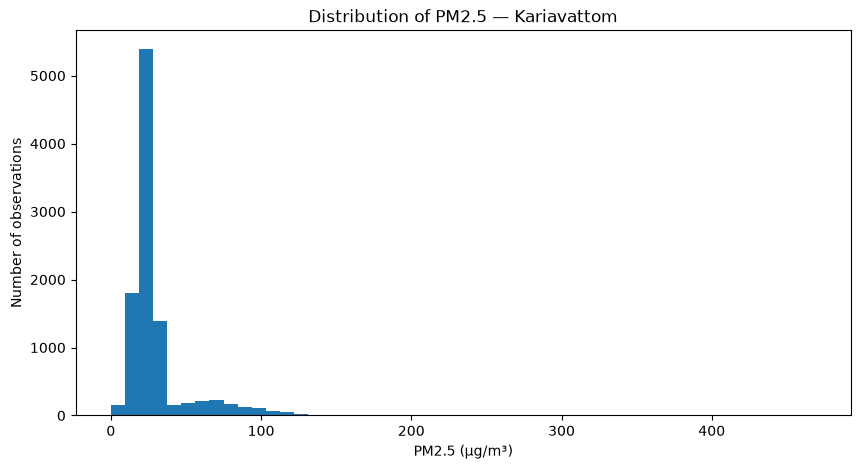

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(df["pm25"], bins=50)
plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("Number of observations")
plt.title("Distribution of PM2.5 — Kariavattom")
plt.show()

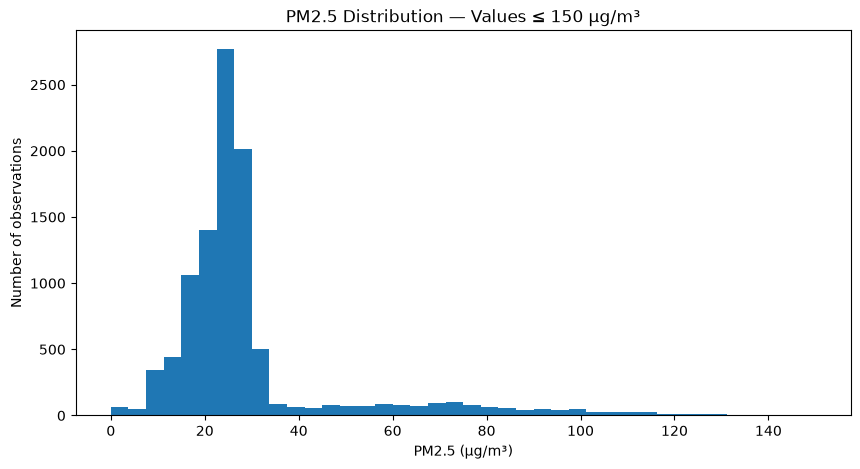

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(
    df.loc[df["pm25"] <= 150, "pm25"],
    bins=40
)

plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("Number of observations")
plt.title("PM2.5 Distribution — Values ≤ 150 µg/m³")
plt.show()

In [ ]:
df["month"] = df["datetime"].dt.to_period("M")

monthly = df.groupby("month")["pm25"].agg(
    ["count", "mean", "median", "min", "max"]
)

print(monthly)

         count       mean  median    min    max
month                                          
2025-02    216  27.537500   27.90  19.30   32.3
2025-03    651  26.238556   26.50  16.80   33.1
2025-04    549  26.045355   26.10  15.70   33.2
2025-05    440  23.804273   24.20   6.25   32.0
2025-06    286  20.874056   21.05   6.56   26.5
2025-07    544  23.261029   24.30  12.40   31.9
2025-08    621  23.252174   24.70  11.20   32.2
2025-09    584  23.051712   23.50   0.00   30.1
2025-10    474  19.576160   17.60   8.58   31.1
2025-11    529  23.336597   23.90   8.86   32.7
2025-12    594  71.100185   73.40   5.68  318.0
2026-01    396  73.512298   69.05   1.00  469.0
2026-02    438  64.185799   59.75   1.00  209.0
2026-03    587  30.126985   26.50   7.13   99.5
2026-04    400  15.927400   14.65   5.00   41.8
2026-05    478  14.920209   16.30   0.00   23.3
2026-06    526  21.375038   24.00   0.00   30.4
2026-07    671  24.571684   24.90  17.30   30.7
2026-08    646  20.982353   22.60  10.60

C:\Users\HP\AppData\Local\Temp\ipykernel_24924\3463115857.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month"] = df["datetime"].dt.to_period("M")


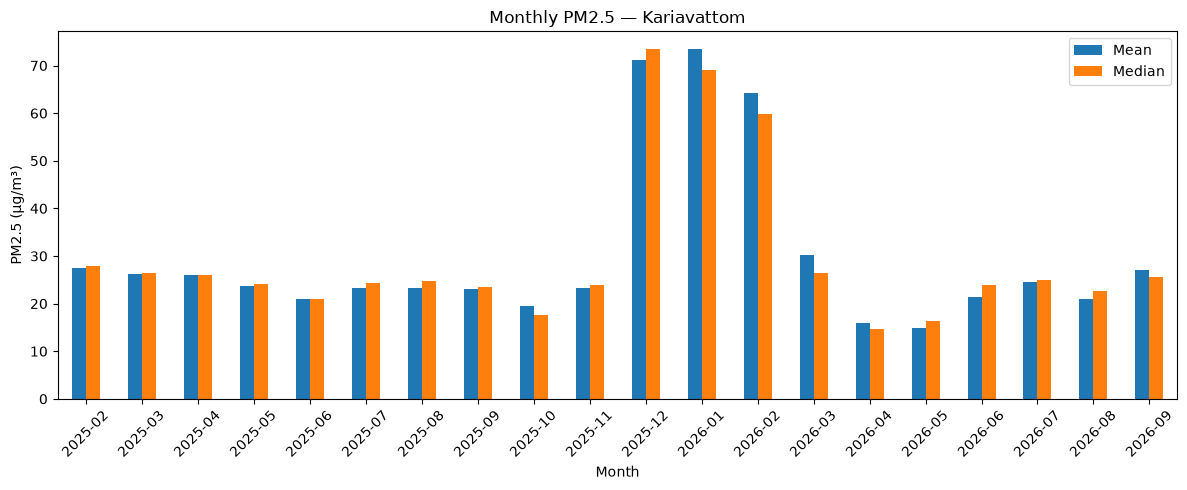

In [ ]:
monthly[["mean", "median"]].plot(
    kind="bar",
    figsize=(12, 5)
)

plt.xlabel("Month")
plt.ylabel("PM2.5 (µg/m³)")
plt.title("Monthly PM2.5 — Kariavattom")
plt.xticks(rotation=45)
plt.legend(["Mean", "Median"])
plt.tight_layout()
plt.show()

In [ ]:
df["date"] = df["datetime"].dt.date

daily = df.groupby("date")["pm25"].agg(
    ["count", "mean", "median", "max"]
)

print(daily.loc["2025-12-01":"2026-02-28"].describe())

TypeError: '<' not supported between instances of 'datetime.date' and 'str'

In [ ]:
df["date"] = df["datetime"].dt.floor("D")

daily = df.groupby("date")["pm25"].agg(
    ["count", "mean", "median", "max"]
)

winter_daily = daily.loc[
    "2025-12-01":"2026-02-28"
]

print(winter_daily.describe())

           count        mean      median         max
count  81.000000   81.000000   81.000000   81.000000
mean   17.629630   70.029266   68.247531  116.103704
std     5.411664   21.082481   21.028993   67.735470
min     2.000000   27.172727   27.800000   29.200000
25%    15.000000   56.535000   55.700000   91.500000
50%    20.000000   74.568182   70.700000  108.000000
75%    22.000000   84.336364   82.400000  123.000000
max    22.000000  111.475000  110.500000  469.000000


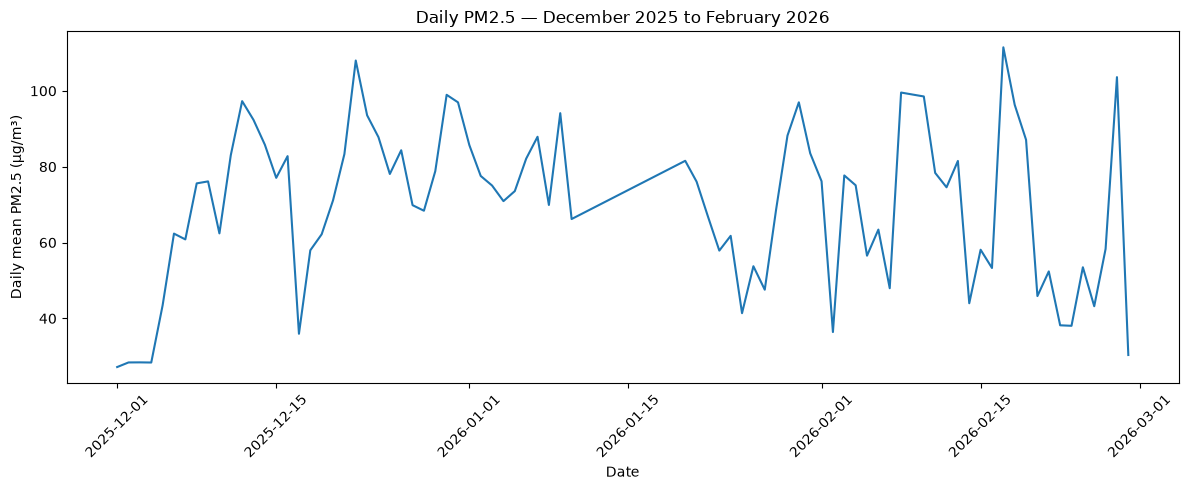

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    winter_daily.index,
    winter_daily["mean"]
)

plt.xlabel("Date")
plt.ylabel("Daily mean PM2.5 (µg/m³)")
plt.title("Daily PM2.5 — December 2025 to February 2026")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df["hour"] = df["datetime"].dt.hour

hourly = df.groupby("hour")["pm25"].agg(
    ["count", "mean", "median"]
)

print(hourly)

      count       mean  median
hour                          
0       111  24.019730   23.90
1       437  31.728513   24.80
2       453  31.345541   25.10
3       456  28.960219   24.75
4       451  28.615188   25.00
5       446  27.649350   24.90
6       432  27.515116   24.65
7       454  28.119780   24.90
8       443  28.768804   24.70
9       427  28.978993   24.60
10      430  27.541395   24.70
11      457  28.647112   24.70
12      457  30.153698   25.30
13      469  30.231727   25.10
14      462  31.440476   24.90
15      454  31.009493   24.90
16      433  30.135150   24.50
17      457  29.946433   24.90
18      461  29.900542   24.90
19      440  31.579409   24.60
20      447  31.685817   24.60
21      451  31.639335   24.60
22      450  32.307267   24.80
23      116  22.695948   23.85


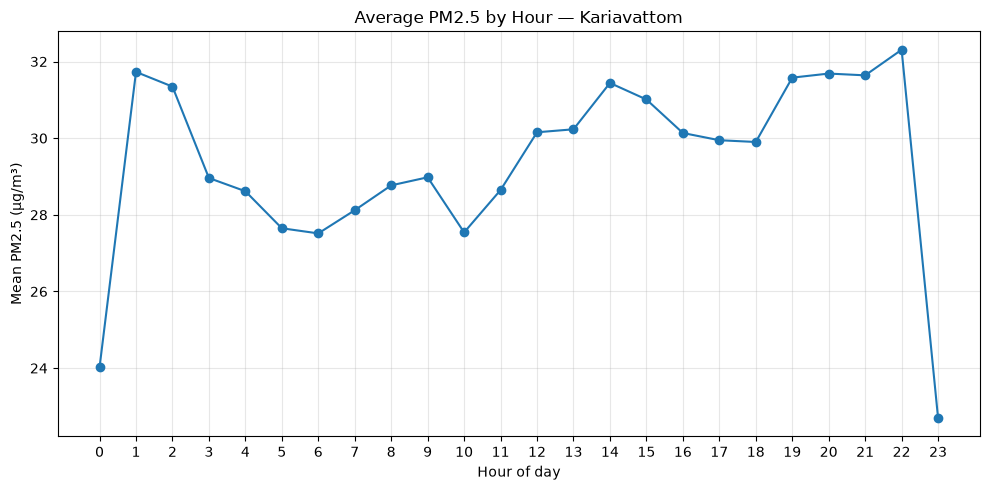

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    hourly.index,
    hourly["mean"],
    marker="o"
)

plt.xlabel("Hour of day")
plt.ylabel("Mean PM2.5 (µg/m³)")
plt.title("Average PM2.5 by Hour — Kariavattom")
plt.xticks(range(24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
daily_counts = df.groupby("date")["pm25"].count()

print(daily_counts.describe())

count    535.000000
mean      18.867290
std        4.885118
min        1.000000
25%       17.000000
50%       21.000000
75%       22.000000
max       24.000000
Name: pm25, dtype: float64


In [ ]:
print("Days with >= 18 observations:", (daily_counts >= 18).sum())
print("Days with >= 12 observations:", (daily_counts >= 12).sum())
print("Days with < 12 observations:", (daily_counts < 12).sum())

Days with >= 18 observations: 391
Days with >= 12 observations: 476
Days with < 12 observations: 59


In [ ]:
daily = df.groupby("date")["pm25"].agg(
    count="count",
    mean="mean",
    median="median",
    max="max"
)

daily_reliable = daily[daily["count"] >= 12].copy()

print("Total days:", len(daily))
print("Reliable days:", len(daily_reliable))
print("Excluded for daily analysis:", len(daily) - len(daily_reliable))

Total days: 535
Reliable days: 476
Excluded for daily analysis: 59


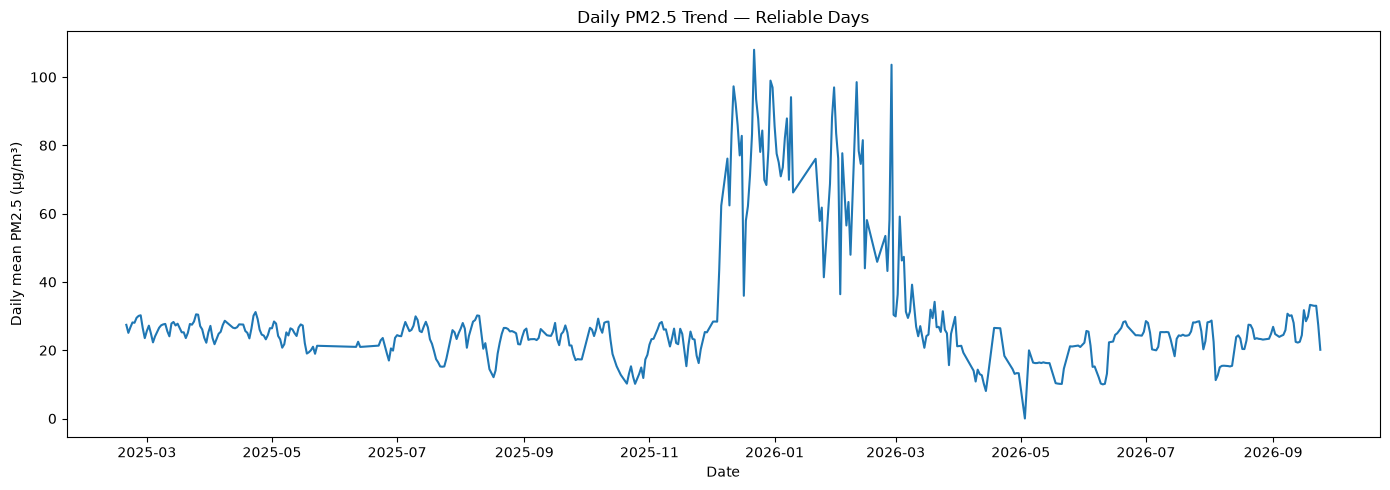

In [ ]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_reliable.index,
    daily_reliable["mean"]
)

plt.xlabel("Date")
plt.ylabel("Daily mean PM2.5 (µg/m³)")
plt.title("Daily PM2.5 Trend — Reliable Days")
plt.tight_layout()
plt.show()

In [ ]:
top_days = daily_reliable.sort_values(
    "mean",
    ascending=False
).head(10)

print(top_days)

                           count        mean  median    max
date                                                       
2025-12-22 00:00:00+05:30     18  107.994444   90.05  318.0
2026-02-27 00:00:00+05:30     22  103.613636   89.05  209.0
2025-12-30 00:00:00+05:30     19   98.952632  108.00  131.0
2026-02-10 00:00:00+05:30     12   98.516667  105.75  127.0
2025-12-12 00:00:00+05:30     19   97.284211   98.60  135.0
2026-01-30 00:00:00+05:30     19   96.973684  102.00  242.0
2025-12-31 00:00:00+05:30     21   96.966667   93.80  126.0
2026-01-09 00:00:00+05:30     14   94.114286   66.60  469.0
2025-12-23 00:00:00+05:30     22   93.550000   95.70  128.0
2025-12-13 00:00:00+05:30     20   92.345000   83.45  150.0


In [ ]:
high_days = daily_reliable[daily_reliable["mean"] >= 50].copy()

print("Days with daily mean >= 50:", len(high_days))
print(high_days[["mean", "median", "count"]].head(20))

Days with daily mean >= 50: 53
                                 mean  median  count
date                                                
2025-12-06 00:00:00+05:30   62.354545   60.25     22
2025-12-09 00:00:00+05:30   76.125000   69.65     20
2025-12-10 00:00:00+05:30   62.409524   62.60     21
2025-12-11 00:00:00+05:30   83.027778   79.05     18
2025-12-12 00:00:00+05:30   97.284211   98.60     19
2025-12-13 00:00:00+05:30   92.345000   83.45     20
2025-12-14 00:00:00+05:30   85.790000   80.45     20
2025-12-15 00:00:00+05:30   77.057895   73.40     19
2025-12-16 00:00:00+05:30   82.784211   73.40     19
2025-12-18 00:00:00+05:30   57.957143   49.60     21
2025-12-19 00:00:00+05:30   62.180952   60.40     21
2025-12-20 00:00:00+05:30   71.128571   78.70     21
2025-12-21 00:00:00+05:30   83.322727   80.20     22
2025-12-22 00:00:00+05:30  107.994444   90.05     18
2025-12-23 00:00:00+05:30   93.550000   95.70     22
2025-12-24 00:00:00+05:30   87.776471   90.50     17
2025-12-25 00:0

In [ ]:
high_days = daily_reliable[daily_reliable["mean"] >= 50].copy()

high_days["new_episode"] = (
    high_days.index.to_series().diff() > pd.Timedelta(days=1)
).cumsum()

episodes = high_days.groupby("new_episode").agg(
    start=("mean", lambda x: x.index.min()),
    end=("mean", lambda x: x.index.max()),
    days=("mean", "size"),
    mean_pm25=("mean", "mean"),
    peak_daily_mean=("mean", "max")
)

print(episodes)

                                start                       end  days  \
new_episode                                                             
0           2025-12-06 00:00:00+05:30 2025-12-06 00:00:00+05:30     1   
1           2025-12-09 00:00:00+05:30 2025-12-16 00:00:00+05:30     8   
2           2025-12-18 00:00:00+05:30 2026-01-10 00:00:00+05:30    24   
3           2026-01-21 00:00:00+05:30 2026-01-21 00:00:00+05:30     1   
4           2026-01-23 00:00:00+05:30 2026-01-24 00:00:00+05:30     2   
5           2026-01-28 00:00:00+05:30 2026-02-01 00:00:00+05:30     5   
6           2026-02-03 00:00:00+05:30 2026-02-03 00:00:00+05:30     1   
7           2026-02-05 00:00:00+05:30 2026-02-06 00:00:00+05:30     2   
8           2026-02-10 00:00:00+05:30 2026-02-13 00:00:00+05:30     4   
9           2026-02-15 00:00:00+05:30 2026-02-15 00:00:00+05:30     1   
10          2026-02-24 00:00:00+05:30 2026-02-24 00:00:00+05:30     1   
11          2026-02-26 00:00:00+05:30 2026-02-27 00

In [ ]:
print("Number of episodes:", len(episodes))
print("Longest episode:", episodes["days"].max(), "days")
print("Average episode duration:", round(episodes["days"].mean(), 1), "days")

print("\nLongest episodes:")
print(
    episodes.sort_values("days", ascending=False)
    [["start", "end", "days", "mean_pm25", "peak_daily_mean"]]
    .head(5)
)

Number of episodes: 13
Longest episode: 24 days
Average episode duration: 4.1 days

Longest episodes:
                                start                       end  days  \
new_episode                                                             
2           2025-12-18 00:00:00+05:30 2026-01-10 00:00:00+05:30    24   
1           2025-12-09 00:00:00+05:30 2025-12-16 00:00:00+05:30     8   
5           2026-01-28 00:00:00+05:30 2026-02-01 00:00:00+05:30     5   
8           2026-02-10 00:00:00+05:30 2026-02-13 00:00:00+05:30     4   
4           2026-01-23 00:00:00+05:30 2026-01-24 00:00:00+05:30     2   

             mean_pm25  peak_daily_mean  
new_episode                              
2            80.095262       107.994444  
1            82.102952        97.284211  
5            82.718528        96.973684  
8            83.242424        98.516667  
4            59.823810        61.771429  


In [ ]:
df["day_of_week"] = df["datetime"].dt.day_name()

weekday = df.groupby("day_of_week")["pm25"].agg(
    ["count", "mean", "median"]
)

weekday = weekday.reindex([
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
])

print(weekday)

             count       mean  median
day_of_week                          
Monday        1352  28.461990    24.3
Tuesday       1468  29.869183    24.5
Wednesday     1508  29.634741    24.6
Thursday      1448  30.092162    24.8
Friday        1501  31.464670    25.1
Saturday      1485  29.609576    25.1
Sunday        1332  29.031464    24.9


In [ ]:
monthly_coverage = df.groupby(
    df["datetime"].dt.to_period("M")
)["pm25"].agg(["count", "mean"])

print(monthly_coverage)

          count       mean
datetime                  
2025-02     216  27.537500
2025-03     651  26.238556
2025-04     549  26.045355
2025-05     440  23.804273
2025-06     286  20.874056
2025-07     544  23.261029
2025-08     621  23.252174
2025-09     584  23.051712
2025-10     474  19.576160
2025-11     529  23.336597
2025-12     594  71.100185
2026-01     396  73.512298
2026-02     438  64.185799
2026-03     587  30.126985
2026-04     400  15.927400
2026-05     478  14.920209
2026-06     526  21.375038
2026-07     671  24.571684
2026-08     646  20.982353
2026-09     464  27.105819


C:\Users\HP\AppData\Local\Temp\ipykernel_24924\1234036929.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["datetime"].dt.to_period("M")


In [ ]:
df["pm25_lag1"] = df["pm25"].shift(1)

print(df[["datetime", "pm25", "pm25_lag1"]].head(10))

                   datetime  pm25  pm25_lag1
0 2025-02-19 02:00:00+05:30  29.2        NaN
1 2025-02-19 03:00:00+05:30  31.3       29.2
2 2025-02-19 04:00:00+05:30  30.5       31.3
3 2025-02-19 05:00:00+05:30  30.3       30.5
4 2025-02-19 06:00:00+05:30  30.5       30.3
5 2025-02-19 07:00:00+05:30  30.2       30.5
6 2025-02-19 08:00:00+05:30  29.9       30.2
7 2025-02-19 09:00:00+05:30  28.8       29.9
8 2025-02-19 10:00:00+05:30  30.2       28.8
9 2025-02-19 11:00:00+05:30  25.4       30.2


In [ ]:
gap_check = df["datetime"].diff()

print(gap_check.value_counts().head(10))

datetime
0 days 01:00:00    9291
0 days 03:00:00     395
0 days 02:00:00     215
0 days 04:00:00      78
0 days 05:00:00      26
0 days 06:00:00      12
0 days 07:00:00       7
0 days 15:00:00       5
0 days 16:00:00       4
0 days 20:00:00       4
Name: count, dtype: int64


In [ ]:
df["pm25_lag1"] = df["pm25"].shift(1)

df.loc[
    df["datetime"].diff() != pd.Timedelta(hours=1),
    "pm25_lag1"
] = pd.NA

print(df[["datetime", "pm25", "pm25_lag1"]].head(10))

                   datetime  pm25  pm25_lag1
0 2025-02-19 02:00:00+05:30  29.2        NaN
1 2025-02-19 03:00:00+05:30  31.3       29.2
2 2025-02-19 04:00:00+05:30  30.5       31.3
3 2025-02-19 05:00:00+05:30  30.3       30.5
4 2025-02-19 06:00:00+05:30  30.5       30.3
5 2025-02-19 07:00:00+05:30  30.2       30.5
6 2025-02-19 08:00:00+05:30  29.9       30.2
7 2025-02-19 09:00:00+05:30  28.8       29.9
8 2025-02-19 10:00:00+05:30  30.2       28.8
9 2025-02-19 11:00:00+05:30  25.4       30.2


In [ ]:
print("Total rows:", len(df))
print("Valid lag-1 values:", df["pm25_lag1"].notna().sum())
print("Missing lag-1 values:", df["pm25_lag1"].isna().sum())

Total rows: 10094
Valid lag-1 values: 9291
Missing lag-1 values: 803


In [ ]:
df["pm25_lag24"] = df["pm25"].shift(1)

time_diff = df["datetime"].diff()

df.loc[
    time_diff != pd.Timedelta(hours=24),
    "pm25_lag24"
] = pd.NA

print(df[["datetime", "pm25", "pm25_lag24"]].head(30))

                    datetime  pm25  pm25_lag24
0  2025-02-19 02:00:00+05:30  29.2         NaN
1  2025-02-19 03:00:00+05:30  31.3         NaN
2  2025-02-19 04:00:00+05:30  30.5         NaN
3  2025-02-19 05:00:00+05:30  30.3         NaN
4  2025-02-19 06:00:00+05:30  30.5         NaN
5  2025-02-19 07:00:00+05:30  30.2         NaN
6  2025-02-19 08:00:00+05:30  29.9         NaN
7  2025-02-19 09:00:00+05:30  28.8         NaN
8  2025-02-19 10:00:00+05:30  30.2         NaN
9  2025-02-19 11:00:00+05:30  25.4         NaN
10 2025-02-19 12:00:00+05:30  25.6         NaN
11 2025-02-19 13:00:00+05:30  23.7         NaN
12 2025-02-19 14:00:00+05:30  24.9         NaN
13 2025-02-19 15:00:00+05:30  24.3         NaN
14 2025-02-19 16:00:00+05:30  26.6         NaN
15 2025-02-19 17:00:00+05:30  25.7         NaN
16 2025-02-19 18:00:00+05:30  26.3         NaN
17 2025-02-19 19:00:00+05:30  25.9         NaN
18 2025-02-19 20:00:00+05:30  26.0         NaN
19 2025-02-19 21:00:00+05:30  25.8         NaN
20 2025-02-19

In [ ]:
df["pm25_lag24"] = (
    df.set_index("datetime")["pm25"]
      .reindex(df["datetime"] - pd.Timedelta(hours=24))
      .to_numpy()
)

print(df[["datetime", "pm25", "pm25_lag24"]].head(30))

                    datetime  pm25  pm25_lag24
0  2025-02-19 02:00:00+05:30  29.2         NaN
1  2025-02-19 03:00:00+05:30  31.3         NaN
2  2025-02-19 04:00:00+05:30  30.5         NaN
3  2025-02-19 05:00:00+05:30  30.3         NaN
4  2025-02-19 06:00:00+05:30  30.5         NaN
5  2025-02-19 07:00:00+05:30  30.2         NaN
6  2025-02-19 08:00:00+05:30  29.9         NaN
7  2025-02-19 09:00:00+05:30  28.8         NaN
8  2025-02-19 10:00:00+05:30  30.2         NaN
9  2025-02-19 11:00:00+05:30  25.4         NaN
10 2025-02-19 12:00:00+05:30  25.6         NaN
11 2025-02-19 13:00:00+05:30  23.7         NaN
12 2025-02-19 14:00:00+05:30  24.9         NaN
13 2025-02-19 15:00:00+05:30  24.3         NaN
14 2025-02-19 16:00:00+05:30  26.6         NaN
15 2025-02-19 17:00:00+05:30  25.7         NaN
16 2025-02-19 18:00:00+05:30  26.3         NaN
17 2025-02-19 19:00:00+05:30  25.9         NaN
18 2025-02-19 20:00:00+05:30  26.0         NaN
19 2025-02-19 21:00:00+05:30  25.8         NaN
20 2025-02-19

In [ ]:
print("Total rows:", len(df))
print("Valid lag-24 values:", df["pm25_lag24"].notna().sum())
print("Missing lag-24 values:", df["pm25_lag24"].isna().sum())

Total rows: 10094
Valid lag-24 values: 8475
Missing lag-24 values: 1619


In [ ]:
df["pm25_rolling24"] = (
    df["pm25"]
      .rolling(window=24, min_periods=18)
      .mean()
)

print(
    df[["datetime", "pm25", "pm25_lag1", "pm25_lag24", "pm25_rolling24"]]
    .tail(10)
)

                       datetime  pm25  pm25_lag1  pm25_lag24  pm25_rolling24
10084 2026-09-24 13:00:00+05:30  20.7       20.2        33.3       20.508333
10085 2026-09-24 14:00:00+05:30  20.1       20.7        30.7       20.066667
10086 2026-09-24 15:00:00+05:30  20.5       20.1        21.0       20.045833
10087 2026-09-24 16:00:00+05:30  19.8       20.5        19.1       20.075000
10088 2026-09-24 17:00:00+05:30  19.7       19.8        19.7       20.075000
10089 2026-09-24 18:00:00+05:30  20.1       19.7        20.1       20.075000
10090 2026-09-24 19:00:00+05:30  21.3       20.1        21.5       20.066667
10091 2026-09-24 20:00:00+05:30  20.1       21.3        19.4       20.095833
10092 2026-09-24 21:00:00+05:30  20.7       20.1        21.3       20.070833
10093 2026-09-24 22:00:00+05:30  20.9       20.7        20.3       20.095833


In [ ]:
df["hour"] = df["datetime"].dt.hour
df["day_of_week_num"] = df["datetime"].dt.dayofweek
df["month_num"] = df["datetime"].dt.month

print(
    df[
        ["datetime", "hour", "day_of_week_num", "month_num"]
    ].tail(10)
)

                       datetime  hour  day_of_week_num  month_num
10084 2026-09-24 13:00:00+05:30    13                3          9
10085 2026-09-24 14:00:00+05:30    14                3          9
10086 2026-09-24 15:00:00+05:30    15                3          9
10087 2026-09-24 16:00:00+05:30    16                3          9
10088 2026-09-24 17:00:00+05:30    17                3          9
10089 2026-09-24 18:00:00+05:30    18                3          9
10090 2026-09-24 19:00:00+05:30    19                3          9
10091 2026-09-24 20:00:00+05:30    20                3          9
10092 2026-09-24 21:00:00+05:30    21                3          9
10093 2026-09-24 22:00:00+05:30    22                3          9


In [ ]:
df["target_pm25_next_hour"] = (
    df.set_index("datetime")["pm25"]
      .reindex(df["datetime"] + pd.Timedelta(hours=1))
      .to_numpy()
)

print(
    df[
        ["datetime", "pm25", "pm25_lag1", "pm25_lag24", "target_pm25_next_hour"]
    ].tail(10)
)

                       datetime  pm25  pm25_lag1  pm25_lag24  \
10084 2026-09-24 13:00:00+05:30  20.7       20.2        33.3   
10085 2026-09-24 14:00:00+05:30  20.1       20.7        30.7   
10086 2026-09-24 15:00:00+05:30  20.5       20.1        21.0   
10087 2026-09-24 16:00:00+05:30  19.8       20.5        19.1   
10088 2026-09-24 17:00:00+05:30  19.7       19.8        19.7   
10089 2026-09-24 18:00:00+05:30  20.1       19.7        20.1   
10090 2026-09-24 19:00:00+05:30  21.3       20.1        21.5   
10091 2026-09-24 20:00:00+05:30  20.1       21.3        19.4   
10092 2026-09-24 21:00:00+05:30  20.7       20.1        21.3   
10093 2026-09-24 22:00:00+05:30  20.9       20.7        20.3   

       target_pm25_next_hour  
10084                   20.1  
10085                   20.5  
10086                   19.8  
10087                   19.7  
10088                   20.1  
10089                   21.3  
10090                   20.1  
10091                   20.7  
10092           

In [ ]:
print("Total rows:", len(df))
print("Valid next-hour targets:", df["target_pm25_next_hour"].notna().sum())
print("Missing next-hour targets:", df["target_pm25_next_hour"].isna().sum())

Total rows: 10094
Valid next-hour targets: 9291
Missing next-hour targets: 803


In [ ]:
model_df = df[
    [
        "datetime",
        "pm25",
        "pm25_lag1",
        "pm25_lag24",
        "pm25_rolling24",
        "hour",
        "day_of_week_num",
        "month_num",
        "target_pm25_next_hour"
    ]
].dropna().copy()

print("ML-ready shape:", model_df.shape)
print()
print(model_df.head())

KeyError: "['datetime', 'pm25_lag1', 'pm25_lag24', 'pm25_rolling24', 'hour', 'day_of_week_num', 'month_num', 'target_pm25_next_hour'] not in index"

In [ ]:
df1 = pd.read_csv("../data/kariavattom_pm25_hourly_2025_feb_sep.csv")
df2 = pd.read_csv("../data/kariavattom_pm25_hourly_2025_oct_2026_mar_clean.csv")

df = pd.concat([df1, df2], ignore_index=True)

In [ ]:
dfs_2026 = [april_clean, may, june, july, august, september_clean]

clean_2026 = []

for raw in dfs_2026:
    ...

NameError: name 'april_clean' is not defined

In [99]:
files_to_combine = [
    "../data/kariavattom_pm25_hourly_2025_feb_sep.csv",
    "../data/kariavattom_pm25_hourly_2025_oct_2026_mar_clean.csv",
    "../data/kariavattom_pm25_hourly_2026_april_clean.csv",
    "../data/kariavattom_pm25_hourly_2026_may_clean.csv",
    "../data/kariavattom_pm25_hourly_2026_june_clean.csv",
    "../data/kariavattom_pm25_hourly_2026_july_clean.csv",
    "../data/kariavattom_pm25_hourly_2026_august_clean.csv",
    "../data/kariavattom_pm25_hourly_2026_september_clean.csv"
]

dfs = [pd.read_csv(f) for f in files_to_combine]

df = pd.concat(dfs, ignore_index=True)

df["datetime"] = pd.to_datetime(df["datetime"])

df = df.sort_values("datetime").reset_index(drop=True)

print("Total rows:", len(df))
print("Missing datetime:", df["datetime"].isna().sum())
print("Duplicate timestamps:", df["datetime"].duplicated().sum())

Total rows: 9651
Missing datetime: 2742
Duplicate timestamps: 2741


In [100]:
import os
import pandas as pd
import requests
from dotenv import load_dotenv

# OpenAQ setup
load_dotenv()
api_key = os.getenv("OPENAQ_API_KEY")
headers = {"X-API-Key": api_key}

sensor_id = 12236173

# Download April–September 2026 with datetime included
months = [
    ("2026-04-01T00:00:00+05:30", "2026-05-01T00:00:00+05:30"),
    ("2026-05-01T00:00:00+05:30", "2026-06-01T00:00:00+05:30"),
    ("2026-06-01T00:00:00+05:30", "2026-07-01T00:00:00+05:30"),
    ("2026-07-01T00:00:00+05:30", "2026-08-01T00:00:00+05:30"),
    ("2026-08-01T00:00:00+05:30", "2026-09-01T00:00:00+05:30"),
    ("2026-09-01T00:00:00+05:30", "2026-09-25T00:00:00+05:30")
]

clean_2026 = []

for start_date, end_date in months:

    response = requests.get(
        f"https://api.openaq.org/v3/sensors/{sensor_id}/hours",
        headers=headers,
        params={
            "datetime_from": start_date,
            "datetime_to": end_date,
            "limit": 1000,
            "page": 1
        }
    )

    response.raise_for_status()

    results = response.json()["results"]

    raw = pd.DataFrame(results)

    raw["percent_coverage"] = raw["coverage"].apply(
        lambda x: x["percentCoverage"] if x else None
    )

    raw["has_flags"] = raw["flagInfo"].apply(
        lambda x: x["hasFlags"] if isinstance(x, dict) else False
    )

    raw["datetime"] = raw["period"].apply(
        lambda x: x["datetimeFrom"]["local"]
    )

    raw["pm25"] = raw["value"]

    # Quality control
    clean = raw[
        (raw["percent_coverage"] >= 75) &
        (raw["has_flags"] == False) &
        (raw["pm25"].notna())
    ].copy()

    clean_2026.append(clean)

# Combine 2026
df_2026 = pd.concat(clean_2026, ignore_index=True)

# Combine with the already-clean 2025/early-2026 data
df1 = pd.read_csv(
    "../data/kariavattom_pm25_hourly_2025_feb_sep.csv"
)

df2 = pd.read_csv(
    "../data/kariavattom_pm25_hourly_2025_oct_2026_mar_clean.csv"
)

df = pd.concat(
    [df1, df2, df_2026],
    ignore_index=True
)

df["datetime"] = pd.to_datetime(df["datetime"])

df = df.sort_values("datetime").reset_index(drop=True)

print("Final dataset ready")
print("Total rows:", len(df))
print("Missing datetime:", df["datetime"].isna().sum())
print("Duplicate timestamps:", df["datetime"].duplicated().sum())
print("First:", df["datetime"].min())
print("Last:", df["datetime"].max())

Final dataset ready
Total rows: 9713
Missing datetime: 0
Duplicate timestamps: 0
First: 2025-02-19 02:00:00+05:30
Last: 2026-09-24 22:00:00+05:30


In [101]:
# Feature engineering

# Previous hour
df["pm25_lag1"] = df["pm25"].shift(1)

df.loc[
    df["datetime"].diff() != pd.Timedelta(hours=1),
    "pm25_lag1"
] = pd.NA

# PM2.5 exactly 24 hours earlier
df["pm25_lag24"] = (
    df.set_index("datetime")["pm25"]
      .reindex(df["datetime"] - pd.Timedelta(hours=24))
      .to_numpy()
)

# 24-hour rolling average
df["pm25_rolling24"] = (
    df["pm25"]
      .rolling(window=24, min_periods=18)
      .mean()
)

# Time features
df["hour"] = df["datetime"].dt.hour
df["day_of_week_num"] = df["datetime"].dt.dayofweek
df["month_num"] = df["datetime"].dt.month

# Next-hour target
df["target_pm25_next_hour"] = (
    df.set_index("datetime")["pm25"]
      .reindex(df["datetime"] + pd.Timedelta(hours=1))
      .to_numpy()
)

print("Feature engineering complete.")
print(df[
    [
        "datetime",
        "pm25",
        "pm25_lag1",
        "pm25_lag24",
        "pm25_rolling24",
        "hour",
        "day_of_week_num",
        "month_num",
        "target_pm25_next_hour"
    ]
].tail())

Feature engineering complete.
                      datetime  pm25  pm25_lag1  pm25_lag24  pm25_rolling24  \
9708 2026-09-24 18:00:00+05:30  20.1       19.7        20.1       20.075000   
9709 2026-09-24 19:00:00+05:30  21.3       20.1        21.5       20.066667   
9710 2026-09-24 20:00:00+05:30  20.1       21.3        19.4       20.095833   
9711 2026-09-24 21:00:00+05:30  20.7       20.1        21.3       20.070833   
9712 2026-09-24 22:00:00+05:30  20.9       20.7        20.3       20.095833   

      hour  day_of_week_num  month_num  target_pm25_next_hour  
9708    18                3          9                   21.3  
9709    19                3          9                   20.1  
9710    20                3          9                   20.7  
9711    21                3          9                   20.9  
9712    22                3          9                    NaN  


In [102]:
model_df = df[
    [
        "datetime",
        "pm25",
        "pm25_lag1",
        "pm25_lag24",
        "pm25_rolling24",
        "hour",
        "day_of_week_num",
        "month_num",
        "target_pm25_next_hour"
    ]
].dropna().copy()

print("ML-ready shape:", model_df.shape)
print()
print(model_df.head())
print()
print(model_df.tail())

ML-ready shape: (6552, 9)

                    datetime  pm25  pm25_lag1  pm25_lag24  pm25_rolling24  \
22 2025-02-20 02:00:00+05:30  26.4       26.1        29.2       27.330435   
23 2025-02-20 03:00:00+05:30  25.5       26.4        31.3       27.254167   
24 2025-02-20 04:00:00+05:30  25.3       25.5        30.5       27.091667   
25 2025-02-20 05:00:00+05:30  24.1       25.3        30.3       26.791667   
26 2025-02-20 06:00:00+05:30  25.9       24.1        30.5       26.600000   

    hour  day_of_week_num  month_num  target_pm25_next_hour  
22     2                3          2                   25.5  
23     3                3          2                   25.3  
24     4                3          2                   24.1  
25     5                3          2                   25.9  
26     6                3          2                   24.8  

                      datetime  pm25  pm25_lag1  pm25_lag24  pm25_rolling24  \
9707 2026-09-24 17:00:00+05:30  19.7       19.8        19.

In [103]:
features = [
    "pm25",
    "pm25_lag1",
    "pm25_lag24",
    "pm25_rolling24",
    "hour",
    "day_of_week_num",
    "month_num"
]

X = model_df[features]
y = model_df["target_pm25_next_hour"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (6552, 7)
Target shape: (6552,)


In [104]:
split_index = int(len(model_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Train end:", model_df["datetime"].iloc[split_index - 1])
print("Test start:", model_df["datetime"].iloc[split_index])

Training rows: 5241
Testing rows: 1311
Train end: 2026-05-15 19:00:00+05:30
Test start: 2026-05-15 20:00:00+05:30


In [105]:
from sklearn.linear_model import LinearRegression

baseline_model = LinearRegression()

baseline_model.fit(X_train, y_train)

print("Baseline model trained successfully.")

Baseline model trained successfully.


In [106]:
y_pred = baseline_model.predict(X_test)

print("Predictions created:", len(y_pred))
print("First 5 predictions:", y_pred[:5])

Predictions created: 1311
First 5 predictions: [17.82009544 17.48031611 15.23437165 15.08995598 15.16893168]


In [107]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 1.3778583032014158
RMSE: 1.9043235235553462
R²: 0.8779483595508305


In [108]:
baseline_results = {
    "Model": "Linear Regression",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
}

print(baseline_results)

{'Model': 'Linear Regression', 'MAE': 1.3778583032014158, 'RMSE': 1.9043235235553462, 'R2': 0.8779483595508305}


In [109]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [110]:
rf_pred = rf_model.predict(X_test)

print("Random Forest predictions created:", len(rf_pred))
print("First 5 predictions:", rf_pred[:5])

Random Forest predictions created: 1311
First 5 predictions: [16.051  16.1025 16.4935 16.269  16.3905]


In [111]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = mean_squared_error(y_test, rf_pred) ** 0.5
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R²:", rf_r2)

Random Forest MAE: 1.274586346300533
Random Forest RMSE: 2.6703008438951077
Random Forest R²: 0.76001585914936


In [112]:
rf_results = {
    "Model": "Random Forest",
    "MAE": rf_mae,
    "RMSE": rf_rmse,
    "R2": rf_r2
}

print(rf_results)

{'Model': 'Random Forest', 'MAE': 1.274586346300533, 'RMSE': 2.6703008438951077, 'R2': 0.76001585914936}


In [113]:
errors = abs(y_test - rf_pred)

print("Largest error:", errors.max())
print("95th percentile error:", errors.quantile(0.95))

Largest error: 21.95049999999999
95th percentile error: 3.5575499999999742


In [114]:
linear_errors = abs(y_test - y_pred)

print("Largest Linear Regression error:", linear_errors.max())
print("95th percentile error:", linear_errors.quantile(0.95))

Largest Linear Regression error: 16.05401614829225
95th percentile error: 3.5346000221153737


In [115]:
worst_index = errors.idxmax()

print("Worst timestamp:", model_df.loc[worst_index, "datetime"])
print("Actual PM2.5:", y_test.loc[worst_index])
print("Random Forest prediction:", rf_pred[list(y_test.index).index(worst_index)])

Worst timestamp: 2026-09-02 00:00:00+05:30
Actual PM2.5: 24.0
Random Forest prediction: 45.95049999999999


In [116]:
print(model_df.loc[worst_index, [
    "datetime",
    "pm25",
    "pm25_lag1",
    "pm25_lag24",
    "pm25_rolling24",
    "hour",
    "day_of_week_num",
    "month_num",
    "target_pm25_next_hour"
]])

datetime                 2026-09-02 00:00:00+05:30
pm25                                          25.6
pm25_lag1                                     26.2
pm25_lag24                                    29.9
pm25_rolling24                              26.825
hour                                             0
day_of_week_num                                  2
month_num                                        9
target_pm25_next_hour                         24.0
Name: 9271, dtype: object


In [117]:
linear_position = list(y_test.index).index(worst_index)

print("Linear Regression prediction:", y_pred[linear_position])
print("Actual PM2.5:", y_test.loc[worst_index])
print("Linear Regression error:", linear_errors.loc[worst_index])

Linear Regression prediction: 25.013390358877512
Actual PM2.5: 24.0
Linear Regression error: 1.013390358877512


In [118]:
results = pd.DataFrame([
    baseline_results,
    rf_results
])

print(results)

               Model       MAE      RMSE        R2
0  Linear Regression  1.377858  1.904324  0.877948
1      Random Forest  1.274586  2.670301  0.760016


In [119]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

print("Gradient Boosting trained successfully.")

Gradient Boosting trained successfully.


In [120]:
gb_pred = gb_model.predict(X_test)

print("Gradient Boosting predictions created:", len(gb_pred))
print("First 5 predictions:", gb_pred[:5])

Gradient Boosting predictions created: 1311
First 5 predictions: [16.44993334 15.87286065 17.05969275 16.44529362 16.44529362]


In [121]:
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = mean_squared_error(y_test, gb_pred) ** 0.5
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting MAE:", gb_mae)
print("Gradient Boosting RMSE:", gb_rmse)
print("Gradient Boosting R²:", gb_r2)

Gradient Boosting MAE: 1.1988754263644983
Gradient Boosting RMSE: 2.0292471191530166
Gradient Boosting R²: 0.8614099559392483


In [122]:
gb_results = {
    "Model": "Gradient Boosting",
    "MAE": gb_mae,
    "RMSE": gb_rmse,
    "R2": gb_r2
}

results_df = pd.DataFrame([
    baseline_results,
    rf_results,
    gb_results
])

results_df

,Model,MAE,RMSE,R2
0,Linear Regression,1.377858,1.904324,0.877948
1,Random Forest,1.274586,2.670301,0.760016
2,Gradient Boosting,1.198875,2.029247,0.861410


In [123]:
results_df.to_csv("../data/model_comparison.csv", index=False)

print("Model comparison saved successfully.")

Model comparison saved successfully.


In [124]:
gb_errors = abs(y_test - gb_pred)

print("Largest error:", gb_errors.max())
print("95th percentile error:", gb_errors.quantile(0.95))

Largest error: 16.540865977494114
95th percentile error: 3.2260973291637516


In [125]:
worst_gb_index = gb_errors.idxmax()

print("Worst timestamp:", model_df.loc[worst_gb_index, "datetime"])
print("Actual:", y_test.loc[worst_gb_index])
print("Predicted:", gb_pred[list(y_test.index).index(worst_gb_index)])
print("Error:", gb_errors.loc[worst_gb_index])

Worst timestamp: 2026-09-14 00:00:00+05:30
Actual: 22.4
Predicted: 38.94086597749411
Error: 16.540865977494114


In [126]:
print(model_df.loc[worst_gb_index, features])

pm25               23.5000
pm25_lag1          22.3000
pm25_lag24         22.8000
pm25_rolling24     22.2625
hour                0.0000
day_of_week_num     0.0000
month_num           9.0000
Name: 9501, dtype: float64


In [127]:
linear_position = list(y_test.index).index(worst_gb_index)

print("Linear prediction:", y_pred[linear_position])
print("Actual:", y_test.loc[worst_gb_index])

Linear prediction: 22.021734498031808
Actual: 22.4


In [128]:
rf_position = list(y_test.index).index(worst_gb_index)

print("Random Forest prediction:", rf_pred[rf_position])
print("Actual:", y_test.loc[worst_gb_index])

Random Forest prediction: 39.69199999999995
Actual: 22.4


In [129]:
print("Linear >5:", (linear_errors > 5).sum())
print("Random Forest >5:", (errors > 5).sum())
print("Gradient Boosting >5:", (gb_errors > 5).sum())

Linear >5: 23
Random Forest >5: 41
Gradient Boosting >5: 30


In [130]:
print("Linear mean absolute error:", linear_errors.mean())
print("Random Forest mean absolute error:", errors.mean())
print("Gradient Boosting mean absolute error:", gb_errors.mean())

Linear mean absolute error: 1.3778583032014158
Random Forest mean absolute error: 1.274586346300533
Gradient Boosting mean absolute error: 1.1988754263644983


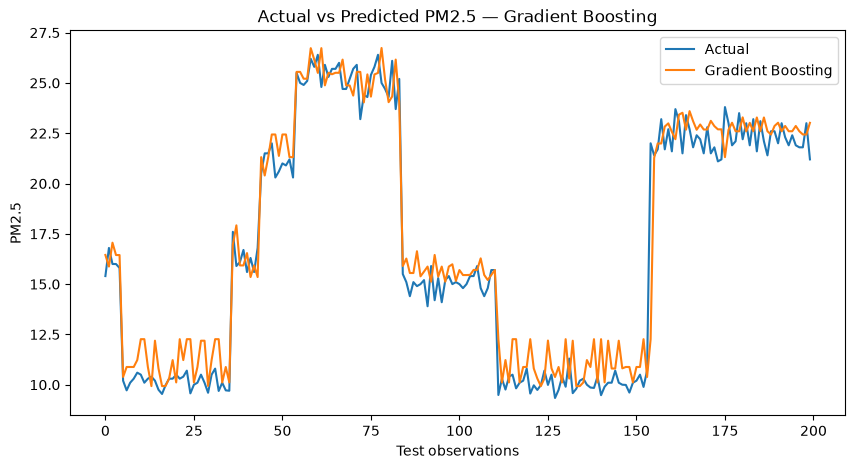

In [131]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(y_test.values[:200], label="Actual")
plt.plot(gb_pred[:200], label="Gradient Boosting")
plt.xlabel("Test observations")
plt.ylabel("PM2.5")
plt.title("Actual vs Predicted PM2.5 — Gradient Boosting")
plt.legend()
plt.show()

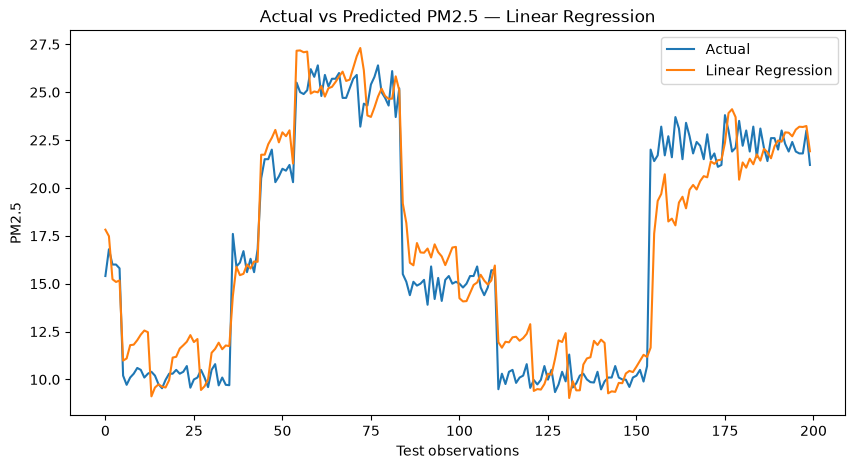

In [132]:
plt.figure(figsize=(10, 5))
plt.plot(y_test.values[:200], label="Actual")
plt.plot(y_pred[:200], label="Linear Regression")
plt.xlabel("Test observations")
plt.ylabel("PM2.5")
plt.title("Actual vs Predicted PM2.5 — Linear Regression")
plt.legend()
plt.show()

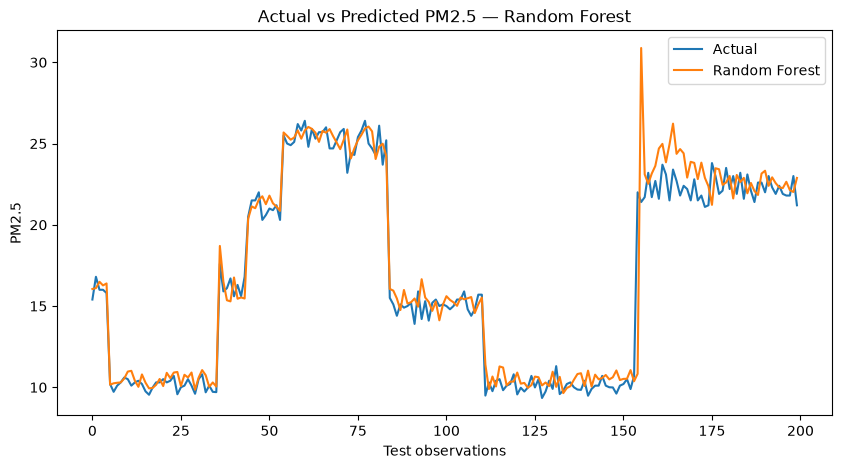

In [133]:
plt.figure(figsize=(10, 5))
plt.plot(y_test.values[:200], label="Actual")
plt.plot(rf_pred[:200], label="Random Forest")
plt.xlabel("Test observations")
plt.ylabel("PM2.5")
plt.title("Actual vs Predicted PM2.5 — Random Forest")
plt.legend()
plt.show()

In [134]:
prediction_df = pd.DataFrame({
    "datetime": model_df.loc[y_test.index, "datetime"].values,
    "actual_pm25": y_test.values,
    "linear_prediction": y_pred,
    "random_forest_prediction": rf_pred,
    "gradient_boosting_prediction": gb_pred
})

prediction_df.to_csv("../data/model_predictions.csv", index=False)

print("Model predictions saved successfully.")

Model predictions saved successfully.


In [135]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": gb_model.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance

,Feature,Importance
0,pm25,0.877026
1,pm25_lag1,0.046242
3,pm25_rolling24,0.043535
2,pm25_lag24,0.016690
4,hour,0.012548
5,day_of_week_num,0.003211
6,month_num,0.000748


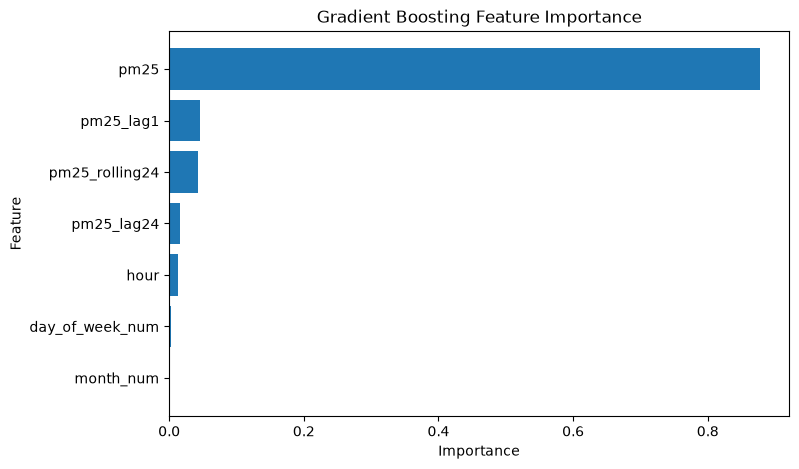

In [136]:
plt.figure(figsize=(8, 5))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Gradient Boosting Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [137]:
feature_importance.to_csv(
    "../data/gradient_boosting_feature_importance.csv",
    index=False
)

print("Feature importance saved successfully.")

Feature importance saved successfully.


In [138]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

print("Time-aware cross-validation ready.")

Time-aware cross-validation ready.


In [139]:
for fold, (train_idx, val_idx) in enumerate(tscv.split(X), start=1):
    print(
        f"Fold {fold}: "
        f"train={len(train_idx)}, "
        f"validation={len(val_idx)}"
    )

Fold 1: train=1092, validation=1092
Fold 2: train=2184, validation=1092
Fold 3: train=3276, validation=1092
Fold 4: train=4368, validation=1092
Fold 5: train=5460, validation=1092


In [140]:
from sklearn.model_selection import cross_validate

cv_results_linear = cross_validate(
    LinearRegression(),
    X,
    y,
    cv=tscv,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    }
)

print("Linear CV MAE:", -cv_results_linear["test_MAE"].mean())
print("Linear CV RMSE:", -cv_results_linear["test_RMSE"].mean())
print("Linear CV R2:", cv_results_linear["test_R2"].mean())

Linear CV MAE: 3.7270732216535216
Linear CV RMSE: 7.0260022054539615
Linear CV R2: 0.7918668689857092


In [141]:
cv_results_rf = cross_validate(
    RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    X,
    y,
    cv=tscv,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    }
)

print("Random Forest CV MAE:", -cv_results_rf["test_MAE"].mean())
print("Random Forest CV RMSE:", -cv_results_rf["test_RMSE"].mean())
print("Random Forest CV R2:", cv_results_rf["test_R2"].mean())

Random Forest CV MAE: 8.996018763736263
Random Forest CV RMSE: 12.60168098131866
Random Forest CV R2: 0.3316064647539268


In [142]:
cv_results_gb = cross_validate(
    GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
    X,
    y,
    cv=tscv,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    }
)

print("Gradient Boosting CV MAE:", -cv_results_gb["test_MAE"].mean())
print("Gradient Boosting CV RMSE:", -cv_results_gb["test_RMSE"].mean())
print("Gradient Boosting CV R2:", cv_results_gb["test_R2"].mean())

Gradient Boosting CV MAE: 9.003716294406685
Gradient Boosting CV RMSE: 12.785791953215556
Gradient Boosting CV R2: 0.35297369345642454


In [143]:
cv_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "CV_MAE": [
        -cv_results_linear["test_MAE"].mean(),
        -cv_results_rf["test_MAE"].mean(),
        -cv_results_gb["test_MAE"].mean()
    ],
    "CV_RMSE": [
        -cv_results_linear["test_RMSE"].mean(),
        -cv_results_rf["test_RMSE"].mean(),
        -cv_results_gb["test_RMSE"].mean()
    ],
    "CV_R2": [
        cv_results_linear["test_R2"].mean(),
        cv_results_rf["test_R2"].mean(),
        cv_results_gb["test_R2"].mean()
    ]
})

cv_comparison.to_csv("../data/time_series_cv_comparison.csv", index=False)

print("Time-aware CV comparison saved successfully.")

Time-aware CV comparison saved successfully.


In [144]:
cv_results_linear["test_MAE"]


array([ -1.01628434,  -0.9223803 , -10.57273326,  -4.77190827,
        -1.35205994])

In [145]:
for fold, (train_idx, val_idx) in enumerate(tscv.split(X), 1):
    print(
        f"Fold {fold}:",
        model_df["datetime"].iloc[val_idx[0]],
        "to",
        model_df["datetime"].iloc[val_idx[-1]]
    )

Fold 1: 2025-04-29 08:00:00+05:30 to 2025-08-16 14:00:00+05:30
Fold 2: 2025-08-16 15:00:00+05:30 to 2025-11-13 15:00:00+05:30
Fold 3: 2025-11-13 16:00:00+05:30 to 2026-02-26 04:00:00+05:30
Fold 4: 2026-02-26 05:00:00+05:30 to 2026-06-17 08:00:00+05:30
Fold 5: 2026-06-17 13:00:00+05:30 to 2026-09-24 21:00:00+05:30


In [146]:
for fold, (train_idx, val_idx) in enumerate(tscv.split(X), 1):
    fold_y = y.iloc[val_idx]
    print(
        f"Fold {fold}:",
        "mean =", round(fold_y.mean(), 2),
        "median =", round(fold_y.median(), 2),
        "max =", round(fold_y.max(), 2)
    )

Fold 1: mean = 23.19 median = 24.0 max = 32.2
Fold 2: mean = 22.48 median = 23.6 max = 32.0
Fold 3: mean = 61.53 median = 63.75 max = 318.0
Fold 4: mean = 24.06 median = 19.1 max = 209.0
Fold 5: mean = 24.86 median = 24.8 max = 35.3


In [147]:
for fold, (train_idx, val_idx) in enumerate(tscv.split(X), 1):
    train_y = y.iloc[train_idx]
    val_y = y.iloc[val_idx]

    print(
        f"Fold {fold}:",
        "train mean =", round(train_y.mean(), 2),
        "| validation mean =", round(val_y.mean(), 2)
    )

Fold 1: train mean = 26.37 | validation mean = 23.19
Fold 2: train mean = 24.78 | validation mean = 22.48
Fold 3: train mean = 24.01 | validation mean = 61.53
Fold 4: train mean = 33.39 | validation mean = 24.06
Fold 5: train mean = 31.52 | validation mean = 24.86


In [148]:
for fold, (train_idx, val_idx) in enumerate(tscv.split(X), 1):
    train_mean = y.iloc[train_idx].mean()
    val_mean = y.iloc[val_idx].mean()
    
    shift = val_mean - train_mean
    
    print(
        f"Fold {fold}: mean shift = {shift:.2f}"
    )

Fold 1: mean shift = -3.18
Fold 2: mean shift = -2.30
Fold 3: mean shift = 37.52
Fold 4: mean shift = -9.33
Fold 5: mean shift = -6.66


In [149]:
for fold, (train_idx, val_idx) in enumerate(tscv.split(X), 1):
    train_mean = X["pm25"].iloc[train_idx].mean()
    val_mean = X["pm25"].iloc[val_idx].mean()

    print(
        f"Fold {fold}: train pm25 = {train_mean:.2f}, "
        f"validation pm25 = {val_mean:.2f}"
    )

Fold 1: train pm25 = 26.37, validation pm25 = 23.19
Fold 2: train pm25 = 24.78, validation pm25 = 22.49
Fold 3: train pm25 = 24.02, validation pm25 = 61.38
Fold 4: train pm25 = 33.36, validation pm25 = 24.19
Fold 5: train pm25 = 31.52, validation pm25 = 24.87


In [150]:
# Create a binary pollution-risk target

model_df["high_pollution_next_hour"] = (
    model_df["target_pm25_next_hour"] >= 40
).astype(int)

print(model_df["high_pollution_next_hour"].value_counts())

high_pollution_next_hour
0    5658
1     894
Name: count, dtype: int64


In [151]:
# Classification features and target

X_class = model_df[features]
y_class = model_df["high_pollution_next_hour"]

print("Features shape:", X_class.shape)
print("Target shape:", y_class.shape)

Features shape: (6552, 7)
Target shape: (6552,)


In [1]:
from sklearn.linear_model import LogisticRegression

split_index = int(len(model_df) * 0.8)

X_class_train = X_class.iloc[:split_index]
X_class_test = X_class.iloc[split_index:]

y_class_train = y_class.iloc[:split_index]
y_class_test = y_class.iloc[split_index:]

print("Training rows:", len(X_class_train))
print("Testing rows:", len(X_class_test))

NameError: name 'model_df' is not defined

In [7]:
model_df = df[
    [
        "datetime",
        "pm25",
        "pm25_lag1",
        "pm25_lag24",
        "pm25_rolling24",
        "hour",
        "day_of_week_num",
        "month_num",
        "target_pm25_next_hour"
    ]
].dropna().copy()

KeyError: "['datetime', 'pm25_lag1', 'pm25_lag24', 'pm25_rolling24', 'hour', 'day_of_week_num', 'month_num', 'target_pm25_next_hour'] not in index"

In [8]:
# Rebuild project ML data after kernel restart

import os
import pandas as pd
import requests
from dotenv import load_dotenv

# Load API key
load_dotenv()
api_key = os.getenv("OPENAQ_API_KEY")
headers = {"X-API-Key": api_key}

# Kariavattom sensor
sensor_id = 12236173

# Download April–September 2026 data
months = [
    ("2026-04-01T00:00:00+05:30", "2026-05-01T00:00:00+05:30"),
    ("2026-05-01T00:00:00+05:30", "2026-06-01T00:00:00+05:30"),
    ("2026-06-01T00:00:00+05:30", "2026-07-01T00:00:00+05:30"),
    ("2026-07-01T00:00:00+05:30", "2026-08-01T00:00:00+05:30"),
    ("2026-08-01T00:00:00+05:30", "2026-09-01T00:00:00+05:30"),
    ("2026-09-01T00:00:00+05:30", "2026-09-25T00:00:00+05:30")
]

clean_2026 = []

for start_date, end_date in months:

    response = requests.get(
        f"https://api.openaq.org/v3/sensors/{sensor_id}/hours",
        headers=headers,
        params={
            "datetime_from": start_date,
            "datetime_to": end_date,
            "limit": 1000,
            "page": 1
        }
    )

    response.raise_for_status()

    results = response.json()["results"]
    raw = pd.DataFrame(results)

    raw["percent_coverage"] = raw["coverage"].apply(
        lambda x: x["percentCoverage"] if x else None
    )

    raw["has_flags"] = raw["flagInfo"].apply(
        lambda x: x["hasFlags"] if isinstance(x, dict) else False
    )

    raw["datetime"] = raw["period"].apply(
        lambda x: x["datetimeFrom"]["local"]
    )

    raw["pm25"] = raw["value"]

    clean = raw[
        (raw["percent_coverage"] >= 75) &
        (raw["has_flags"] == False) &
        (raw["pm25"].notna())
    ].copy()

    clean_2026.append(clean)

df_2026 = pd.concat(clean_2026, ignore_index=True)

# Load previously cleaned data
df1 = pd.read_csv("../data/kariavattom_pm25_hourly_2025_feb_sep.csv")
df2 = pd.read_csv("../data/kariavattom_pm25_hourly_2025_oct_2026_mar_clean.csv")

# Combine everything
df = pd.concat([df1, df2, df_2026], ignore_index=True)

df["datetime"] = pd.to_datetime(df["datetime"])

df = (
    df
    .sort_values("datetime")
    .reset_index(drop=True)
)

# -----------------------------
# Feature engineering
# -----------------------------

# Previous hour
df["pm25_lag1"] = df["pm25"].shift(1)

# Do not use lag1 across gaps
df.loc[
    df["datetime"].diff() != pd.Timedelta(hours=1),
    "pm25_lag1"
] = pd.NA

# PM2.5 exactly 24 hours earlier
df["pm25_lag24"] = (
    df.set_index("datetime")["pm25"]
      .reindex(df["datetime"] - pd.Timedelta(hours=24))
      .to_numpy()
)

# 24-hour rolling average
df["pm25_rolling24"] = (
    df["pm25"]
      .rolling(window=24, min_periods=18)
      .mean()
)

# Time features
df["hour"] = df["datetime"].dt.hour
df["day_of_week_num"] = df["datetime"].dt.dayofweek
df["month_num"] = df["datetime"].dt.month

# Next-hour target
df["target_pm25_next_hour"] = (
    df.set_index("datetime")["pm25"]
      .reindex(df["datetime"] + pd.Timedelta(hours=1))
      .to_numpy()
)

# -----------------------------
# ML-ready dataset
# -----------------------------

model_df = df[
    [
        "datetime",
        "pm25",
        "pm25_lag1",
        "pm25_lag24",
        "pm25_rolling24",
        "hour",
        "day_of_week_num",
        "month_num",
        "target_pm25_next_hour"
    ]
].dropna().copy()

# -----------------------------
# Classification target
# -----------------------------

model_df["high_pollution_next_hour"] = (
    model_df["target_pm25_next_hour"] >= 40
).astype(int)

# Features
features = [
    "pm25",
    "pm25_lag1",
    "pm25_lag24",
    "pm25_rolling24",
    "hour",
    "day_of_week_num",
    "month_num"
]

X_class = model_df[features]
y_class = model_df["high_pollution_next_hour"]

print("Dataset rebuilt successfully!")
print("ML-ready shape:", model_df.shape)
print("Classification features:", X_class.shape)
print("Classification target:", y_class.shape)
print()
print(y_class.value_counts())

Dataset rebuilt successfully!
ML-ready shape: (6552, 10)
Classification features: (6552, 7)
Classification target: (6552,)

high_pollution_next_hour
0    5658
1     894
Name: count, dtype: int64


In [9]:
# Time-aware train/test split for classification

split_index = int(len(model_df) * 0.8)

X_class_train = X_class.iloc[:split_index]
X_class_test = X_class.iloc[split_index:]

y_class_train = y_class.iloc[:split_index]
y_class_test = y_class.iloc[split_index:]

print("Training rows:", len(X_class_train))
print("Testing rows:", len(X_class_test))

print("Training positive cases:", y_class_train.sum())
print("Testing positive cases:", y_class_test.sum())

Training rows: 5241
Testing rows: 1311
Training positive cases: 894
Testing positive cases: 0


In [10]:
print("Train period:")
print(model_df["datetime"].iloc[0])
print("to")
print(model_df["datetime"].iloc[split_index - 1])

print("\nTest period:")
print(model_df["datetime"].iloc[split_index])
print("to")
print(model_df["datetime"].iloc[-1])

print("\nMaximum target PM2.5 in test:", y_class_test.max())
print("Positive cases in test:", y_class_test.sum())

Train period:
2025-02-20 02:00:00+05:30
to
2026-05-15 19:00:00+05:30

Test period:
2026-05-15 20:00:00+05:30
to
2026-09-24 21:00:00+05:30

Maximum target PM2.5 in test: 0
Positive cases in test: 0


In [11]:
# Check elevated-pollution cases across time-series folds

from sklearn.model_selection import TimeSeriesSplit

tscv_class = TimeSeriesSplit(n_splits=5)

for fold, (train_idx, val_idx) in enumerate(
    tscv_class.split(X_class), start=1
):
    train_positive = y_class.iloc[train_idx].sum()
    val_positive = y_class.iloc[val_idx].sum()

    print(
        f"Fold {fold}: "
        f"train={len(train_idx)}, "
        f"validation={len(val_idx)}, "
        f"train positives={train_positive}, "
        f"validation positives={val_positive}"
    )

Fold 1: train=1092, validation=1092, train positives=0, validation positives=0
Fold 2: train=2184, validation=1092, train positives=0, validation positives=0
Fold 3: train=3276, validation=1092, train positives=0, validation positives=774
Fold 4: train=4368, validation=1092, train positives=774, validation positives=120
Fold 5: train=5460, validation=1092, train positives=894, validation positives=0


In [12]:
# Check possible classification thresholds

for threshold in [25, 30, 35, 40, 45, 50, 60]:
    positive_count = (model_df["target_pm25_next_hour"] >= threshold).sum()
    positive_percent = positive_count / len(model_df) * 100

    print(
        f"Threshold {threshold}: "
        f"{positive_count} positive cases "
        f"({positive_percent:.1f}%)"
    )

Threshold 25: 3321 positive cases (50.7%)
Threshold 30: 1338 positive cases (20.4%)
Threshold 35: 955 positive cases (14.6%)
Threshold 40: 894 positive cases (13.6%)
Threshold 45: 839 positive cases (12.8%)
Threshold 50: 766 positive cases (11.7%)
Threshold 60: 633 positive cases (9.7%)


In [13]:
# Check time-series coverage using a 30 µg/m³ project threshold

y_class_30 = (
    model_df["target_pm25_next_hour"] >= 30
).astype(int)

for fold, (train_idx, val_idx) in enumerate(
    tscv_class.split(X_class), start=1
):
    train_positive = y_class_30.iloc[train_idx].sum()
    val_positive = y_class_30.iloc[val_idx].sum()

    print(
        f"Fold {fold}: "
        f"train positives={train_positive}, "
        f"validation positives={val_positive}"
    )

Fold 1: train positives=115, validation positives=50
Fold 2: train positives=165, validation positives=17
Fold 3: train positives=182, validation positives=815
Fold 4: train positives=997, validation positives=224
Fold 5: train positives=1221, validation positives=117


In [14]:
# Final classification target: elevated pollution at 30 µg/m³

model_df["high_pollution_next_hour"] = (
    model_df["target_pm25_next_hour"] >= 30
).astype(int)

X_class = model_df[features]
y_class = model_df["high_pollution_next_hour"]

print("Classification dataset ready")
print("Features:", X_class.shape)
print("Target:", y_class.shape)
print()
print(y_class.value_counts())

Classification dataset ready
Features: (6552, 7)
Target: (6552,)

high_pollution_next_hour
0    5214
1    1338
Name: count, dtype: int64


In [15]:
from sklearn.linear_model import LogisticRegression

# Time-aware train/test split
split_index = int(len(model_df) * 0.8)

X_class_train = X_class.iloc[:split_index]
X_class_test = X_class.iloc[split_index:]

y_class_train = y_class.iloc[:split_index]
y_class_test = y_class.iloc[split_index:]

# Train Logistic Regression
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_class_train, y_class_train)

# Predictions
logistic_pred = logistic_model.predict(X_class_test)
logistic_prob = logistic_model.predict_proba(X_class_test)[:, 1]

print("Logistic Regression trained successfully!")
print("Training rows:", len(X_class_train))
print("Testing rows:", len(X_class_test))

Logistic Regression trained successfully!
Training rows: 5241
Testing rows: 1311


In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

accuracy = accuracy_score(y_class_test, logistic_pred)
precision = precision_score(y_class_test, logistic_pred, zero_division=0)
recall = recall_score(y_class_test, logistic_pred, zero_division=0)
f1 = f1_score(y_class_test, logistic_pred, zero_division=0)
roc_auc = roc_auc_score(y_class_test, logistic_prob)

cm = confusion_matrix(y_class_test, logistic_pred)

print("Logistic Regression results")
print("---------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

print("\nConfusion Matrix:")
print(cm)

Logistic Regression results
---------------------------
Accuracy : 0.9107551487414187
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC-AUC  : 0.9575727641054275

Confusion Matrix:
[[1194    0]
 [ 117    0]]


In [17]:
# Inspect Logistic Regression probability scores

print("Minimum probability:", logistic_prob.min())
print("Maximum probability:", logistic_prob.max())
print("Mean probability:", logistic_prob.mean())

print("\nProbability percentiles:")
print(
    pd.Series(logistic_prob).quantile(
        [0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

Minimum probability: 0.001523685255073365
Maximum probability: 0.27249453140292945
Mean probability: 0.051958546147217816

Probability percentiles:
0.50    0.038947
0.75    0.071284
0.90    0.115315
0.95    0.139712
0.99    0.219418
dtype: float64


In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Evaluate different probability thresholds

for threshold in [0.05, 0.10, 0.15, 0.20, 0.25]:
    threshold_pred = (logistic_prob >= threshold).astype(int)

    precision = precision_score(
        y_class_test,
        threshold_pred,
        zero_division=0
    )

    recall = recall_score(
        y_class_test,
        threshold_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_class_test,
        threshold_pred,
        zero_division=0
    )

    print(
        f"Threshold {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f} | "
        f"Predicted elevated: {threshold_pred.sum()}"
    )

Threshold 0.05 | Precision: 0.236 | Recall: 0.991 | F1: 0.381 | Predicted elevated: 492
Threshold 0.10 | Precision: 0.534 | Recall: 0.812 | F1: 0.644 | Predicted elevated: 178
Threshold 0.15 | Precision: 0.907 | Recall: 0.419 | F1: 0.573 | Predicted elevated: 54
Threshold 0.20 | Precision: 1.000 | Recall: 0.171 | F1: 0.292 | Predicted elevated: 20
Threshold 0.25 | Precision: 1.000 | Recall: 0.060 | F1: 0.113 | Predicted elevated: 7


In [19]:
# Confusion matrix at probability threshold 0.10

threshold = 0.10

logistic_pred_010 = (
    logistic_prob >= threshold
).astype(int)

cm_010 = confusion_matrix(
    y_class_test,
    logistic_pred_010
)

print("Confusion Matrix at threshold 0.10:")
print(cm_010)

print("\nPredicted elevated cases:", logistic_pred_010.sum())
print("Actual elevated cases:", y_class_test.sum())

Confusion Matrix at threshold 0.10:
[[1111   83]
 [  22   95]]

Predicted elevated cases: 178
Actual elevated cases: 117
